# Agricultural Futures Final Project

## Strategy Evaluation Notebook

This notebook assumes the data engineering work is already complete.

Prepared inputs:
- [corn_futures_data_builder.ipynb](./corn_futures_data_builder.ipynb)
- [wheat_futures_data_builder.ipynb](./wheat_futures_data_builder.ipynb)
- [mod13a2_ndvi_data_builder.ipynb](./mod13a2_ndvi_data_builder.ipynb)

Research framing for this version:
1. convert NASA NDVI into a seasonally adjusted crop-health anomaly
2. treat future realized NDVI anomaly as an oracle stand-in for weather-model skill
3. compare realistic forecast lead buckets: `basic`, `advanced`, and `expert`
4. evaluate both standalone crop-health signals and NDVI-gated course strategies
5. compare the resulting sleeves before building a combined portfolio in a later step

In [90]:
from pathlib import Path
import os
import warnings
from itertools import combinations


def locate_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data_ag_futures').exists() and (candidate / 'notebooks_ag_futures').exists():
            return candidate
    raise FileNotFoundError('Could not locate a project root containing data_ag_futures and notebooks_ag_futures.')


PROJECT_ROOT = locate_project_root()
NOTEBOOKS_ROOT = PROJECT_ROOT / 'notebooks_ag_futures'
os.environ.setdefault('MPLCONFIGDIR', str(NOTEBOOKS_ROOT / '.mplconfig'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

DATA_ROOT = PROJECT_ROOT / 'data_ag_futures'
PROCESSED_DIR = DATA_ROOT / 'processed'

CORN_CACHE_PATH = PROCESSED_DIR / 'corn_continuous_back_adjusted.csv'
WHEAT_CACHE_PATH = PROCESSED_DIR / 'wheat_continuous_back_adjusted.csv'
NDVI_LEVEL_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_level_series.csv'
NDVI_DAILY_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_daily_series.csv'

MA_PAIRS = [(10, 30), (30, 100), (80, 160)]
PRIMARY_PAIR = (30, 100)
PAIRS_HORIZONS = (5, 10, 20)
RUN_WHEAT_PAIRS_ANALYSIS = True
REGIME_NEUTRAL_SCALE = 0.5
ANOMALY_Z_THRESHOLD = 0.75
ACTIVE_CROP_MONTHS = (4, 5, 6, 7, 8, 9, 10)
LEAD_SCENARIOS = {
    'basic': 14,
    'advanced': 45,
    'expert': 90,
}
LEAD_RATIONALE = {
    'basic': '14 days: aligned with official 8-14 day outlook horizons.',
    'advanced': '45 days: sub-seasonal horizon consistent with 2-6 week forecast products.',
    'expert': '90 days: seasonal quarter-ahead crop outlook, treated as a strong but still plausible institutional edge.',
}


def annualized_sharpe(returns, periods=252):
    series = pd.Series(returns).dropna()
    if series.empty or series.std() == 0:
        return np.nan
    return np.sqrt(periods) * series.mean() / series.std()


def max_drawdown(returns):
    series = pd.Series(returns).fillna(0.0)
    wealth = (1.0 + series).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def summarize_strategy(name, returns, signal=None):
    series = pd.Series(returns).dropna()
    if series.empty:
        cum_return = np.nan
        ann_vol = np.nan
        mdd = np.nan
    else:
        cum_return = (1.0 + series).prod() - 1.0
        ann_vol = series.std() * np.sqrt(252)
        mdd = max_drawdown(series)
    summary = {
        'strategy': name,
        'obs': int(series.shape[0]),
        'cum_return': cum_return,
        'ann_sharpe': annualized_sharpe(series),
        'ann_vol': ann_vol,
        'max_drawdown': mdd,
    }
    if signal is not None:
        sig = pd.Series(signal).dropna()
        summary['active_share'] = sig.abs().mean() if not sig.empty else np.nan
    return summary


def summary_table(rows, sort=False):
    frame = pd.DataFrame(rows).set_index('strategy')
    if sort:
        frame = frame.sort_values('ann_sharpe', ascending=False)
    return frame.round(4)


def cumulative_return(returns):
    series = pd.Series(returns).fillna(0.0)
    return (1.0 + series).cumprod() - 1.0


def plot_cumulative_returns(frame, title, figsize=(12, 6), linewidth=2.0, ncol=2):
    fig, ax = plt.subplots(figsize=figsize)
    for column in frame.columns:
        cumulative_return(frame[column]).plot(ax=ax, label=column, linewidth=linewidth)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=ncol)
    plt.tight_layout()
    plt.show()


def display_bullets(title, lines):
    body = '\n'.join(f'- {line}' for line in lines)
    display(Markdown(f'### {title}\n{body}'))


def require_file(path, label):
    if not path.exists():
        raise FileNotFoundError(f'{label} not found at {path}. Build it in the corresponding data-builder notebook first.')
    return path


def load_futures_cache(path, label):
    require_file(path, label)
    frame = pd.read_csv(path, parse_dates=['Date']).set_index('Date').sort_index()
    required = ['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']
    missing = [column for column in required if column not in frame.columns]
    if missing:
        raise ValueError(f'{label} cache is missing required columns: {missing}')
    return frame


def load_ndvi_caches(level_path, daily_path):
    require_file(level_path, 'NDVI level cache')
    require_file(daily_path, 'NDVI daily cache')
    ndvi_level = pd.read_csv(level_path, parse_dates=['date']).set_index('date').sort_index()
    ndvi_daily = pd.read_csv(daily_path, parse_dates=['Date']).set_index('Date').sort_index()
    required_daily = ['ndvi', 'ndvi_roll_mean', 'ndvi_roll_std', 'ndvi_z', 'ndvi_regime']
    missing = [column for column in required_daily if column not in ndvi_daily.columns]
    if missing:
        raise ValueError(f'NDVI daily cache is missing required columns: {missing}')
    return ndvi_level, ndvi_daily


def add_ma_signals(frame, pairs):
    data = frame.copy()
    daily_pct = data['Adj_Close_Futures'].pct_change()
    for short_window, long_window in pairs:
        short_col = f'ma{short_window}'
        long_col = f'ma{long_window}'
        signal_col = f'signal_{short_window}_{long_window}'
        strat_col = f'strategy_ret_{short_window}_{long_window}'
        data[short_col] = daily_pct.rolling(short_window).mean()
        data[long_col] = daily_pct.rolling(long_window).mean()
        signal = pd.Series(
            np.where(data[short_col] > data[long_col], 1.0, -1.0),
            index=data.index,
            dtype='float64',
        )
        signal[data[short_col].isna() | data[long_col].isna()] = np.nan
        data[signal_col] = signal
        data[strat_col] = data[signal_col].shift(1) * data['futures_ret']
    return data


def build_signal_strategy(signal, futures_ret, lag=1):
    signal = pd.Series(signal, dtype='float64')
    futures_ret = pd.Series(futures_ret).reindex(signal.index)
    returns = signal.shift(lag) * futures_ret
    return pd.DataFrame({'signal': signal, 'strategy_return': returns})


def apply_regime_filter(signal, regime, neutral_scale=REGIME_NEUTRAL_SCALE):
    signal = pd.Series(signal, dtype='float64')
    regime = pd.Series(regime, dtype='float64').reindex(signal.index)
    filtered = signal.copy()
    flat_mask = signal.eq(0.0)
    filtered.loc[flat_mask] = 0.0
    active_mask = signal.notna() & regime.notna() & ~flat_mask
    filtered.loc[active_mask] = np.where(
        regime.loc[active_mask] == np.sign(signal.loc[active_mask]),
        signal.loc[active_mask],
        np.where(regime.loc[active_mask] == 0.0, neutral_scale * signal.loc[active_mask], 0.0),
    )
    return filtered


def run_countertrend_strategy(frame, p=2.2, avg_range_window=20, prior_high_window=20):
    data = frame[['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']].copy()
    data['DayRange'] = data['High'] - data['Low']
    data['Av20R'] = data['DayRange'].shift(1).rolling(avg_range_window).mean()
    data['PrvHiWRoll'] = data['High'].shift(1).rolling(prior_high_window).max()
    data['HitLevel'] = data['PrvHiWRoll'] - (p * data['Av20R'])
    data['Hit?'] = data['Low'] < data['HitLevel']
    data['HitAt'] = np.where(data['Open'] < data['HitLevel'], data['Open'], data['HitLevel'])
    data['HitAt'] = np.where(data['Hit?'], data['HitAt'], np.nan)
    data['ExitPr'] = data['Close']
    data['strategy_return'] = np.where(data['Hit?'], (data['ExitPr'] - data['HitAt']) / data['HitAt'], 0.0)
    data['signal'] = np.where(data['Hit?'], 1.0, 0.0)
    return data


def run_vol_regime_strategy(frame, vol_window=20, z_window=250, neutral_low=0.0, neutral_high=0.5):
    data = frame[['futures_ret']].copy()
    data['vol20'] = data['futures_ret'].rolling(vol_window).std()
    mean_ref = data['vol20'].shift(1).rolling(z_window).mean()
    std_ref = data['vol20'].shift(1).rolling(z_window).std()
    data['zvol20'] = (data['vol20'] - mean_ref) / std_ref
    data['signal'] = np.where((data['zvol20'] < neutral_low) | (data['zvol20'] > neutral_high), 1.0, -1.0)
    data.loc[data['zvol20'].isna(), 'signal'] = np.nan
    data['strategy_return'] = data['signal'].shift(1) * data['futures_ret']
    return data


def dickey_fuller_diagnostics(spread):
    series = pd.Series(spread).dropna()
    test = pd.DataFrame({'spread': series})
    test['delta_spread'] = test['spread'].diff()
    test['lag_spread'] = test['spread'].shift(1)
    test = test.dropna()
    model = sm.OLS(test['delta_spread'], sm.add_constant(test['lag_spread'])).fit()
    adf_stat, pvalue, n_lags, n_obs, critical_values, _ = adfuller(series, regression='c', autolag='AIC')
    return {
        'df_tstat_regression': float(model.tvalues['lag_spread']),
        'adf_stat': float(adf_stat),
        'pvalue': float(pvalue),
        'critical_10pct': critical_values['10%'],
        'critical_5pct': critical_values['5%'],
        'critical_1pct': critical_values['1%'],
        'observations': int(n_obs),
    }


def build_pairs_panel(corn_frame, wheat_frame, horizons=PAIRS_HORIZONS):
    pair = pd.DataFrame({
        'corn': corn_frame['Adj_Close_Futures'],
        'wheat': wheat_frame['Adj_Close_Futures'],
    }).dropna().copy()
    pair['spread_price'] = pair['corn'] - pair['wheat']
    pair['ret1CORN'] = pair['corn'].pct_change()
    pair['ret1WHEAT'] = pair['wheat'].pct_change()
    for horizon in horizons:
        for label in ['CORN', 'WHEAT']:
            price_col = 'corn' if label == 'CORN' else 'wheat'
            pair[f'{label}_ret{horizon}'] = pair[price_col].pct_change(horizon)
            pair[f'z{label}{horizon}'] = (
                (pair[f'{label}_ret{horizon}'] - pair[f'{label}_ret{horizon}'].shift(1).rolling(60).mean())
                / pair[f'{label}_ret{horizon}'].shift(1).rolling(60).std()
            )
        pair[f'zdiff{horizon}'] = pair[f'zCORN{horizon}'] - pair[f'zWHEAT{horizon}']
    pair['vol20CORN'] = pair['ret1CORN'].rolling(20).std()
    pair['vol20WHEAT'] = pair['ret1WHEAT'].rolling(20).std()
    pair['invvolCORN'] = 1.0 / pair['vol20CORN']
    pair['invvolWHEAT'] = 1.0 / pair['vol20WHEAT']
    pair['sum_invvol'] = pair['invvolCORN'] + pair['invvolWHEAT']
    pair['wCORN'] = pair['invvolCORN'] / pair['sum_invvol']
    pair['wWHEAT'] = pair['invvolWHEAT'] / pair['sum_invvol']
    pair['future_spread_ret'] = pair['wCORN'] * pair['ret1CORN'].shift(-1) - pair['wWHEAT'] * pair['ret1WHEAT'].shift(-1)
    return pair


def run_pairs_position_strategy(spread_col, fret1, long_entry=-1.0, short_entry=1.0, long_cap=1.0, short_cap=-1.0, max_holding=5):
    age = 0
    ages = []
    positions = []
    current_position = 0
    for spread in spread_col:
        if current_position == 1 and (spread >= long_cap or age >= max_holding):
            current_position = 0
            age = 0
        elif current_position == -1 and (spread <= short_cap or age >= max_holding):
            current_position = 0
            age = 0
        if current_position == 0:
            if spread <= long_entry:
                current_position = 1
                age = 1
            elif spread >= short_entry:
                current_position = -1
                age = 1
        else:
            age += 1
        ages.append(age)
        positions.append(current_position)
    results = pd.DataFrame({'position': positions, 'age': ages}, index=pd.Index(spread_col.index))
    results['strategy_return'] = results['position'] * fret1
    return results


def build_ndvi_anomaly_panel(ndvi_daily):
    panel = ndvi_daily.copy()
    month_day = pd.Series(panel.index.strftime('%m-%d'), index=panel.index)
    seasonal_mean = panel.groupby(month_day)['ndvi'].mean()
    seasonal_std = panel.groupby(month_day)['ndvi'].std().replace(0.0, np.nan)
    panel['seasonal_mean'] = month_day.map(seasonal_mean)
    panel['seasonal_std'] = month_day.map(seasonal_std)
    panel['ndvi_anomaly'] = panel['ndvi'] - panel['seasonal_mean']
    panel['ndvi_anomaly_z'] = panel['ndvi_anomaly'] / panel['seasonal_std']
    return panel


def make_crop_health_regime(anomaly_z, threshold=ANOMALY_Z_THRESHOLD, active_months=ACTIVE_CROP_MONTHS):
    z = pd.Series(anomaly_z, dtype='float64')
    regime = pd.Series(np.nan, index=z.index, dtype='float64')
    active_mask = z.index.month.isin(active_months)
    regime.loc[active_mask] = np.where(
        z.loc[active_mask] <= -threshold,
        1.0,
        np.where(z.loc[active_mask] >= threshold, -1.0, 0.0),
    )
    return regime


def add_oracle_lead_signals(frame, leads):
    data = frame.copy()
    for label, horizon in leads.items():
        future_col = f'future_ndvi_anomaly_z_{label}'
        regime_col = f'crop_regime_{label}'
        signal_col = f'crop_signal_{label}'
        return_col = f'crop_return_{label}'
        data[future_col] = data['ndvi_anomaly_z'].shift(-horizon)
        data[regime_col] = make_crop_health_regime(data[future_col])
        data[signal_col] = data[regime_col].fillna(0.0)
        data[return_col] = data[signal_col].shift(1) * data['futures_ret']
    return data


def register_strategy(name, returns, signal=None):
    strategy_return_streams[name] = pd.Series(returns).rename(name)
    strategy_summary_map[name] = summarize_strategy(name, returns, signal)


def annualized_return(returns, periods=252):
    series = pd.Series(returns).dropna()
    if series.empty:
        return np.nan
    return series.mean() * periods


def apply_regime_to_strategy_returns(signal, base_return, regime, signal_lag=0):
    base_signal = pd.Series(signal, dtype='float64')
    base_return = pd.Series(base_return).reindex(base_signal.index)
    filtered_signal = apply_regime_filter(base_signal, regime)

    scale_signal = base_signal.shift(signal_lag) if signal_lag else base_signal
    filtered_scale_signal = filtered_signal.shift(signal_lag) if signal_lag else filtered_signal

    scale = pd.Series(0.0, index=base_signal.index, dtype='float64')
    active = scale_signal.notna() & scale_signal.ne(0.0)
    scale.loc[active] = filtered_scale_signal.loc[active] / scale_signal.loc[active]
    scale.loc[scale_signal.isna()] = np.nan

    filtered_return = base_return * scale
    filtered_return.loc[scale_signal.eq(0.0)] = 0.0
    return pd.DataFrame({'signal': filtered_signal, 'strategy_return': filtered_return})


def portfolio_statistics(weights, returns_frame):
    clean = returns_frame.dropna()
    portfolio = clean.dot(np.asarray(weights))
    return {
        'ann_return': annualized_return(portfolio),
        'ann_vol': portfolio.std() * np.sqrt(252),
        'ann_sharpe': annualized_sharpe(portfolio),
        'cum_return': (1.0 + portfolio).prod() - 1.0,
        'max_drawdown': max_drawdown(portfolio),
    }


def optimize_long_only_sharpe(returns_frame, starts=6, random_state=42):
    clean = returns_frame.dropna()
    n_assets = clean.shape[1]
    if n_assets == 0:
        raise ValueError('No assets supplied to optimizer.')
    rng = np.random.default_rng(random_state)
    initial_points = [np.repeat(1.0 / n_assets, n_assets)]
    for _ in range(max(starts - 1, 0)):
        initial_points.append(rng.dirichlet(np.ones(n_assets)))

    bounds = [(0.0, 1.0)] * n_assets
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    def objective(weights):
        portfolio = clean.to_numpy() @ weights
        vol = portfolio.std()
        if vol == 0 or np.isnan(vol):
            return 1e6
        return -(np.sqrt(252) * portfolio.mean() / vol)

    best_result = None
    best_value = np.inf
    for x0 in initial_points:
        result = minimize(
            objective,
            x0=x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-9},
        )
        if result.success and result.fun < best_value:
            best_result = result
            best_value = result.fun

    if best_result is None:
        weights = pd.Series(initial_points[0], index=clean.columns, dtype='float64')
    else:
        weights = pd.Series(best_result.x, index=clean.columns, dtype='float64')

    weights = weights.clip(lower=0.0)
    weights = weights / weights.sum()
    return weights, portfolio_statistics(weights.values, clean)


def optimize_strategy_subsets(returns_frame, min_size=1, max_size=None):
    clean = returns_frame.dropna()
    columns = list(clean.columns)
    if max_size is None:
        max_size = len(columns)
    rows = []
    for size in range(min_size, max_size + 1):
        for subset in combinations(columns, size):
            subset_frame = clean[list(subset)]
            weights, stats = optimize_long_only_sharpe(subset_frame, random_state=100 + size)
            active_weights = weights[weights > 1e-6]
            row = {
                'subset_size': size,
                'strategies': ' + '.join(subset),
                'effective_size': int(active_weights.shape[0]),
                'active_strategies': ' + '.join(active_weights.index.tolist()),
            }
            row.update(stats)
            for name, value in weights.items():
                row[f'w_{name}'] = value
            rows.append(row)
    return pd.DataFrame(rows).sort_values('ann_sharpe', ascending=False).reset_index(drop=True)


def sample_random_portfolios(returns_frame, n_samples=6000, random_state=42):
    clean = returns_frame.dropna()
    columns = list(clean.columns)
    rng = np.random.default_rng(random_state)
    rows = []
    for _ in range(n_samples):
        subset_size = int(rng.integers(1, len(columns) + 1))
        subset_idx = rng.choice(len(columns), size=subset_size, replace=False)
        weights = np.zeros(len(columns))
        weights[subset_idx] = rng.dirichlet(np.ones(subset_size))
        stats = portfolio_statistics(weights, clean[columns])
        rows.append({
            'ann_return': stats['ann_return'],
            'ann_vol': stats['ann_vol'],
            'ann_sharpe': stats['ann_sharpe'],
            'subset_size': subset_size,
        })
    return pd.DataFrame(rows)


def extract_weight_series(row, candidate_names):
    weights = pd.Series({name: row.get(f'w_{name}', 0.0) for name in candidate_names}, dtype='float64')
    weights = weights[weights > 1e-8].sort_values(ascending=False)
    return weights / weights.sum()


## Prepare data

Load the prepared futures and NDVI caches, then convert the NDVI series from a raw vegetation level into a seasonally adjusted crop-health anomaly.

In [91]:
corn = load_futures_cache(CORN_CACHE_PATH, 'corn futures cache')
corn = add_ma_signals(corn, MA_PAIRS)
ndvi_level, ndvi_daily = load_ndvi_caches(NDVI_LEVEL_CACHE_PATH, NDVI_DAILY_CACHE_PATH)
ndvi_panel = build_ndvi_anomaly_panel(ndvi_daily)
corn_ndvi = corn.join(ndvi_panel[['ndvi', 'seasonal_mean', 'seasonal_std', 'ndvi_anomaly', 'ndvi_anomaly_z']], how='inner')
corn_ndvi = add_oracle_lead_signals(corn_ndvi, LEAD_SCENARIOS)

wheat = load_futures_cache(WHEAT_CACHE_PATH, 'wheat futures cache') if RUN_WHEAT_PAIRS_ANALYSIS and WHEAT_CACHE_PATH.exists() else None

strategy_return_streams = {}
strategy_summary_map = {}
register_strategy('buy_and_hold', corn['futures_ret'])

data_rows = [
    {'dataset': 'corn futures', 'rows': len(corn), 'start': corn.index.min().date(), 'end': corn.index.max().date()},
    {'dataset': 'ndvi daily', 'rows': len(ndvi_daily), 'start': ndvi_daily.index.min().date(), 'end': ndvi_daily.index.max().date()},
    {'dataset': 'corn + ndvi overlap', 'rows': len(corn_ndvi), 'start': corn_ndvi.index.min().date(), 'end': corn_ndvi.index.max().date()},
]
if wheat is not None:
    data_rows.append({'dataset': 'wheat futures', 'rows': len(wheat), 'start': wheat.index.min().date(), 'end': wheat.index.max().date()})

display(pd.DataFrame(data_rows))

display_bullets(
    'Lead assumptions',
    [
        LEAD_RATIONALE['basic'],
        LEAD_RATIONALE['advanced'],
        LEAD_RATIONALE['expert'],
        'The crop-health regime is active only in April through October so winter vegetation weakness does not mechanically suppress futures signals.'
    ],
)

,dataset,rows,start,end
0,corn futures,6452,2000-07-17,2026-04-30
1,ndvi daily,9546,2000-02-18,2026-04-07
2,corn + ndvi overlap,6435,2000-07-17,2026-04-07
3,wheat futures,6464,2000-07-17,2026-04-30


### Lead assumptions
- 14 days: aligned with official 8-14 day outlook horizons.
- 45 days: sub-seasonal horizon consistent with 2-6 week forecast products.
- 90 days: seasonal quarter-ahead crop outlook, treated as a strong but still plausible institutional edge.
- The crop-health regime is active only in April through October so winter vegetation weakness does not mechanically suppress futures signals.

## NASA crop-health signal: build seasonal anomaly

The notebook now uses NDVI anomaly rather than raw NDVI level. The idea is to compare each date with its normal seasonal vegetation state and isolate unusually strong or weak crop conditions.

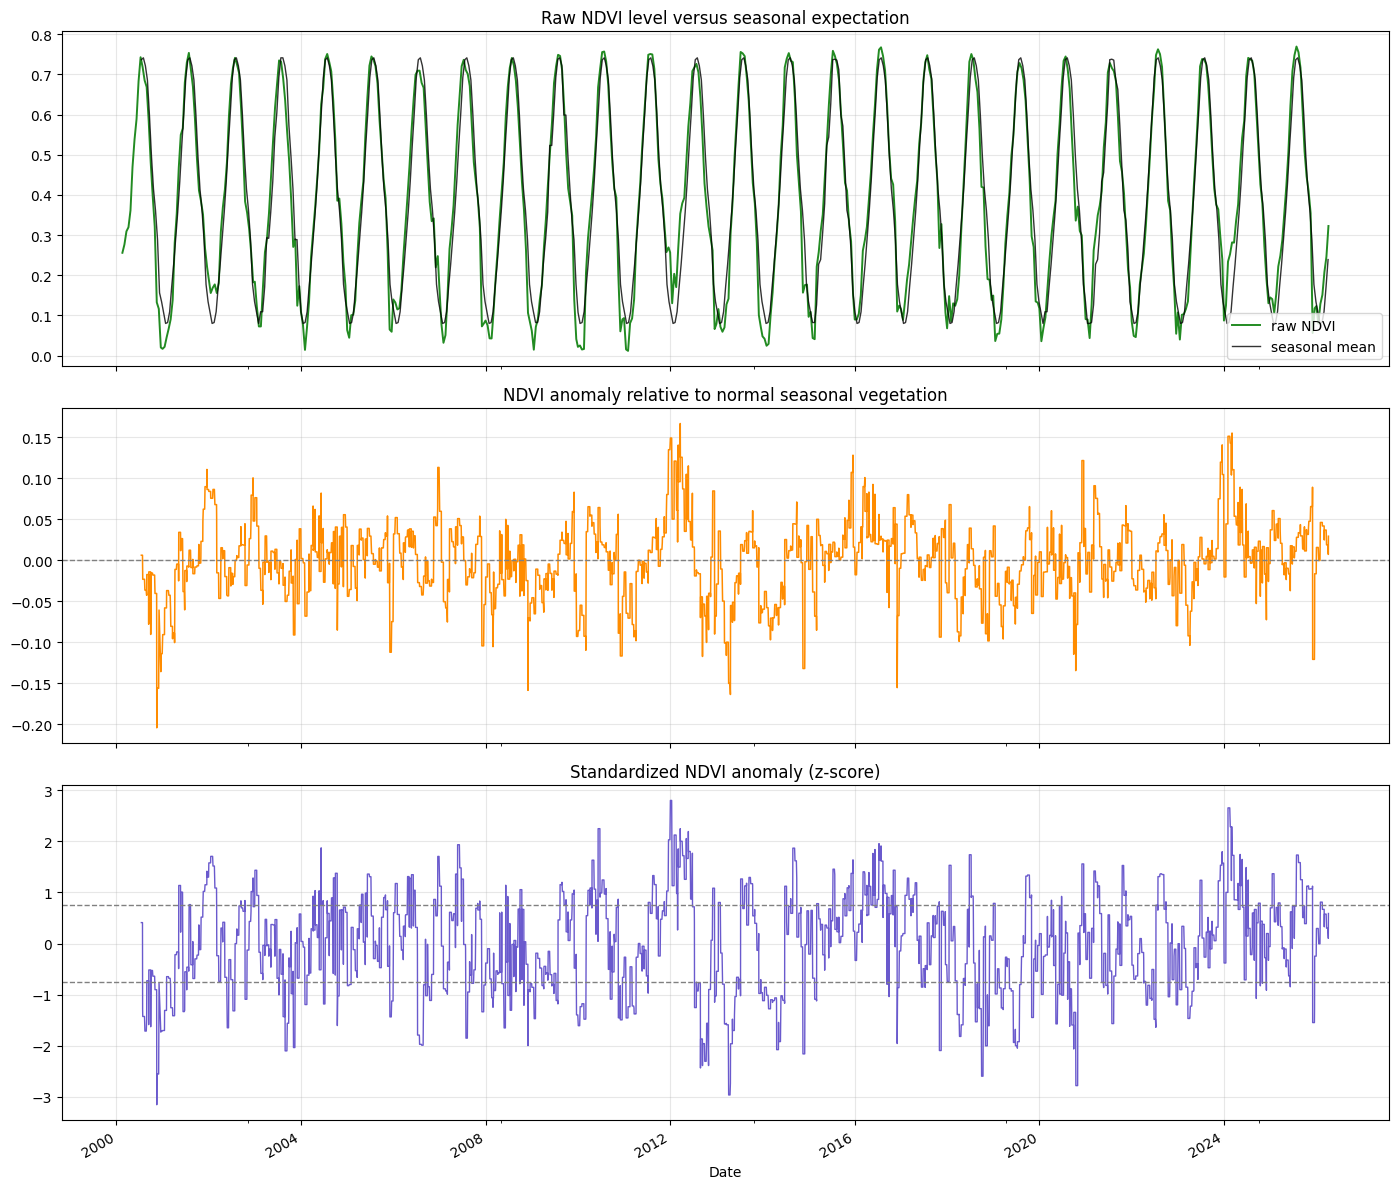

### Why anomaly instead of level
- Raw NDVI is heavily seasonal and mostly tells you that summer looks like summer and winter looks like winter.
- The anomaly isolates whether crop health is unusually strong or weak for that time of year.
- The crop-health logic is only active during the crop window, which covers 58.9% of daily observations.

In [92]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ndvi_level['ndvi'].plot(ax=axes[0], color='forestgreen', linewidth=1.4, label='raw NDVI')
corn_ndvi['seasonal_mean'].resample('16D').first().plot(ax=axes[0], color='black', linewidth=1.0, alpha=0.8, label='seasonal mean')
axes[0].set_title('Raw NDVI level versus seasonal expectation')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

corn_ndvi['ndvi_anomaly'].plot(ax=axes[1], color='darkorange', linewidth=1.1)
axes[1].axhline(0.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('NDVI anomaly relative to normal seasonal vegetation')
axes[1].grid(True, alpha=0.3)

corn_ndvi['ndvi_anomaly_z'].plot(ax=axes[2], color='slateblue', linewidth=1.0)
axes[2].axhline(-ANOMALY_Z_THRESHOLD, color='gray', linestyle='--', linewidth=1)
axes[2].axhline(ANOMALY_Z_THRESHOLD, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Standardized NDVI anomaly (z-score)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

active_share = corn_ndvi.index.month.isin(ACTIVE_CROP_MONTHS).mean()
display_bullets(
    'Why anomaly instead of level',
    [
        'Raw NDVI is heavily seasonal and mostly tells you that summer looks like summer and winter looks like winter.',
        'The anomaly isolates whether crop health is unusually strong or weak for that time of year.',
        f'The crop-health logic is only active during the crop window, which covers {active_share:.1%} of daily observations.'
    ],
)

## NASA crop-health signal: oracle lead scenarios

Treat future realized NDVI anomaly as a perfect-foresight stand-in for a weather model. This is not a live tradable signal. It is a theoretical benchmark for how much value forecast skill could create.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
ndvi_oracle_advanced,6434,3.7248,0.4328,0.1759,-0.5678,0.2687
ndvi_oracle_basic,6434,0.5290,0.1828,0.1732,-0.6053,0.2735
ndvi_oracle_expert,6434,0.5098,0.1790,0.1758,-0.5623,0.2678


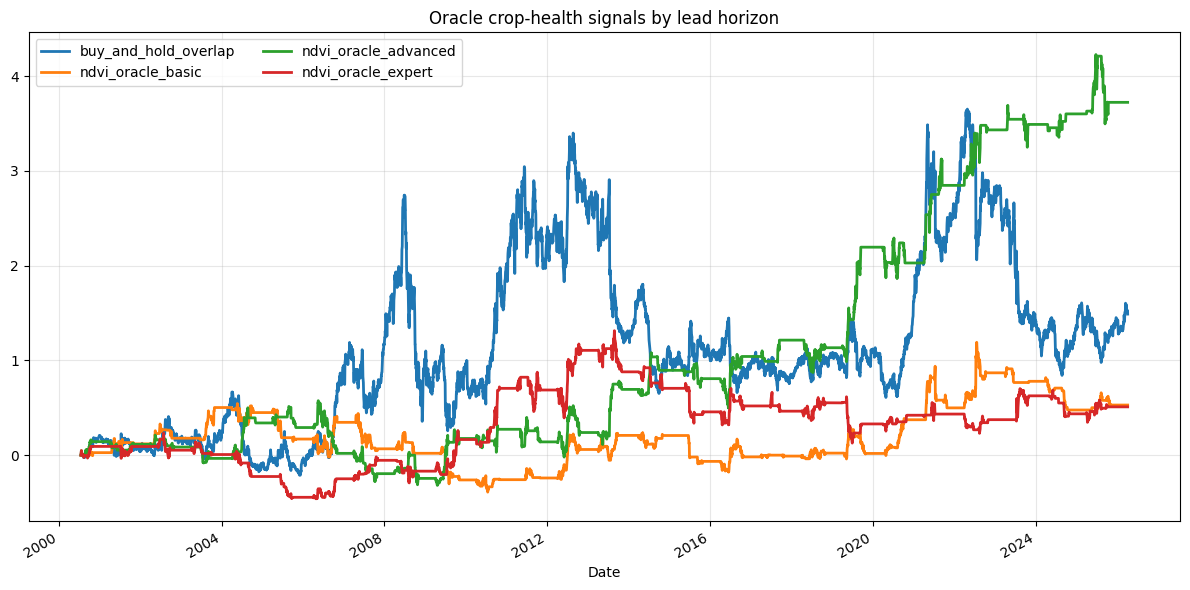

### Interpretation
- The strongest standalone oracle lead is `ndvi_oracle_advanced` with Sharpe 0.43.
- These returns should be interpreted as a forecast-skill ceiling, not as a live implementable strategy.
- If a longer lead still works well, then earlier crop-health information is more economically valuable.

In [93]:
lead_rows = []
for label in LEAD_SCENARIOS:
    name = f'ndvi_oracle_{label}'
    signal_col = f'crop_signal_{label}'
    return_col = f'crop_return_{label}'
    register_strategy(name, corn_ndvi[return_col], corn_ndvi[signal_col])
    lead_rows.append(summarize_strategy(name, corn_ndvi[return_col], corn_ndvi[signal_col]))

lead_summary = summary_table(lead_rows, sort=True)
display(lead_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold_overlap': corn_ndvi['futures_ret'],
        'ndvi_oracle_basic': corn_ndvi['crop_return_basic'],
        'ndvi_oracle_advanced': corn_ndvi['crop_return_advanced'],
        'ndvi_oracle_expert': corn_ndvi['crop_return_expert'],
    }),
    'Oracle crop-health signals by lead horizon',
    figsize=(12, 6),
    ncol=2,
)

best_lead = lead_summary.index[0]
display_bullets(
    'Interpretation',
    [
        f'The strongest standalone oracle lead is `{best_lead}` with Sharpe {lead_summary.iloc[0]["ann_sharpe"]:.2f}.',
        'These returns should be interpreted as a forecast-skill ceiling, not as a live implementable strategy.',
        'If a longer lead still works well, then earlier crop-health information is more economically valuable.'
    ],
)

## Trend strategies: create

Build the three course moving-average sleeves first, before testing whether crop-health foresight improves the primary trend rule.

In [94]:
trend_rows = [summarize_strategy('buy_and_hold', corn['futures_ret'])]
for short_window, long_window in MA_PAIRS:
    name = f'ma_{short_window}_{long_window}'
    signal_col = f'signal_{short_window}_{long_window}'
    return_col = f'strategy_ret_{short_window}_{long_window}'
    register_strategy(name, corn[return_col], corn[signal_col])
    trend_rows.append(summarize_strategy(name, corn[return_col], corn[signal_col]))

trend_summary = summary_table(trend_rows)

## Trend strategies: evaluate

Compare the plain moving-average sleeves against buy-and-hold and identify the strongest ungated trend baseline.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
ma_10_30,6421,2.7582,0.3231,0.3082,-0.5738,1.0
ma_30_100,6351,-0.8379,-0.0780,0.3093,-0.9389,1.0
ma_80_160,6291,-0.1554,0.1340,0.3103,-0.8763,1.0


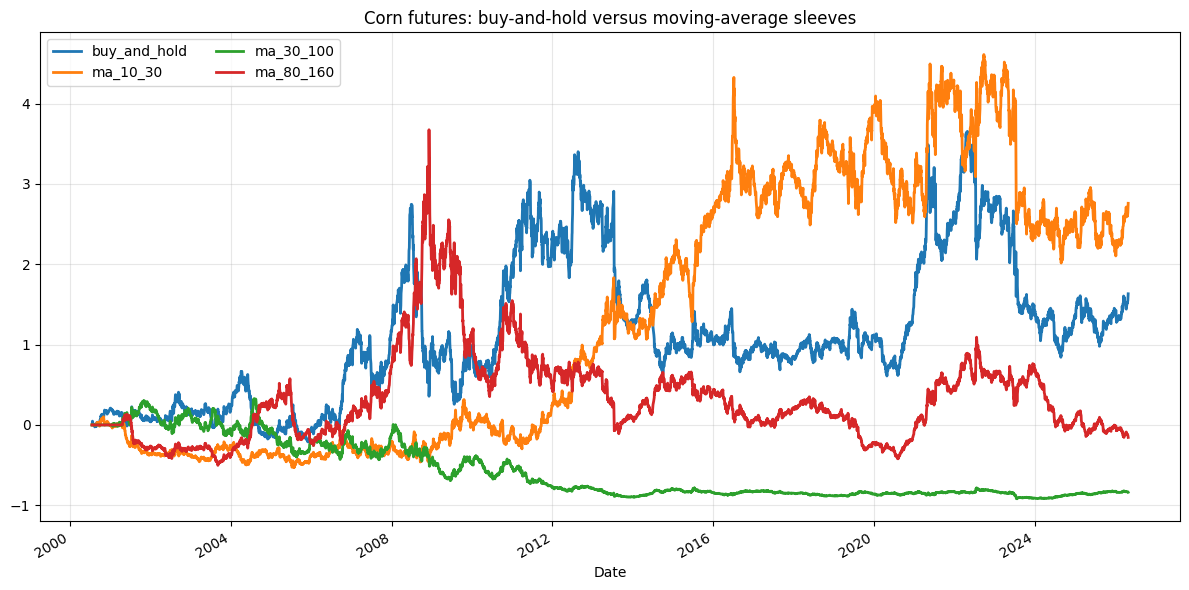

### Interpretation
- The strongest plain trend sleeve is `ma_10_30` with Sharpe 0.32.
- The `30/100` rule remains the primary trend baseline for crop-health gating because it is closest to the course framing.

In [95]:
display(trend_summary)

trend_plot = pd.DataFrame({'buy_and_hold': corn['futures_ret']})
for short_window, long_window in MA_PAIRS:
    trend_plot[f'ma_{short_window}_{long_window}'] = corn[f'strategy_ret_{short_window}_{long_window}']
plot_cumulative_returns(
    trend_plot,
    'Corn futures: buy-and-hold versus moving-average sleeves',
    figsize=(12, 6),
    ncol=2,
)

best_plain_trend = trend_summary.drop(index='buy_and_hold')['ann_sharpe'].idxmax()
display_bullets(
    'Interpretation',
    [
        f'The strongest plain trend sleeve is `{best_plain_trend}` with Sharpe {trend_summary.loc[best_plain_trend, "ann_sharpe"]:.2f}.',
        'The `30/100` rule remains the primary trend baseline for crop-health gating because it is closest to the course framing.'
    ],
)

## Trend strategies: apply crop-health leads

Filter the primary `30/100` trend rule with each crop-health lead bucket to see how much forecast horizon matters.

In [96]:
trend_lead_rows = [
    summarize_strategy('buy_and_hold_overlap', corn_ndvi['futures_ret']),
    summarize_strategy('ma_30_100', corn_ndvi['strategy_ret_30_100'], corn_ndvi['signal_30_100']),
]

for label in LEAD_SCENARIOS:
    name = f'ma_30_100_ndvi_{label}'
    filtered_signal = apply_regime_filter(corn_ndvi['signal_30_100'], corn_ndvi[f'crop_regime_{label}'])
    filtered_panel = build_signal_strategy(filtered_signal, corn_ndvi['futures_ret'], lag=1)
    corn_ndvi[f'{name}_signal'] = filtered_panel['signal']
    corn_ndvi[f'{name}_return'] = filtered_panel['strategy_return']
    register_strategy(name, filtered_panel['strategy_return'], filtered_panel['signal'])
    trend_lead_rows.append(summarize_strategy(name, filtered_panel['strategy_return'], filtered_panel['signal']))

trend_lead_summary = summary_table(trend_lead_rows, sort=True)

## Evaluate NDVI-led trend variants

The key question here is not whether current NDVI helps, but how far ahead crop-health information would need to arrive to materially improve a trend system.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold_overlap,6434,1.4893,0.2708,0.3080,-0.6644,NaN
ma_30_100_ndvi_advanced,6334,-0.6449,-0.0591,0.2339,-0.8495,0.7219
ma_30_100,6334,-0.8297,-0.0718,0.3096,-0.9389,1.0000
ma_30_100_ndvi_basic,6334,-0.7855,-0.1475,0.2321,-0.8830,0.7112
ma_30_100_ndvi_expert,6334,-0.7945,-0.1521,0.2339,-0.8906,0.7084


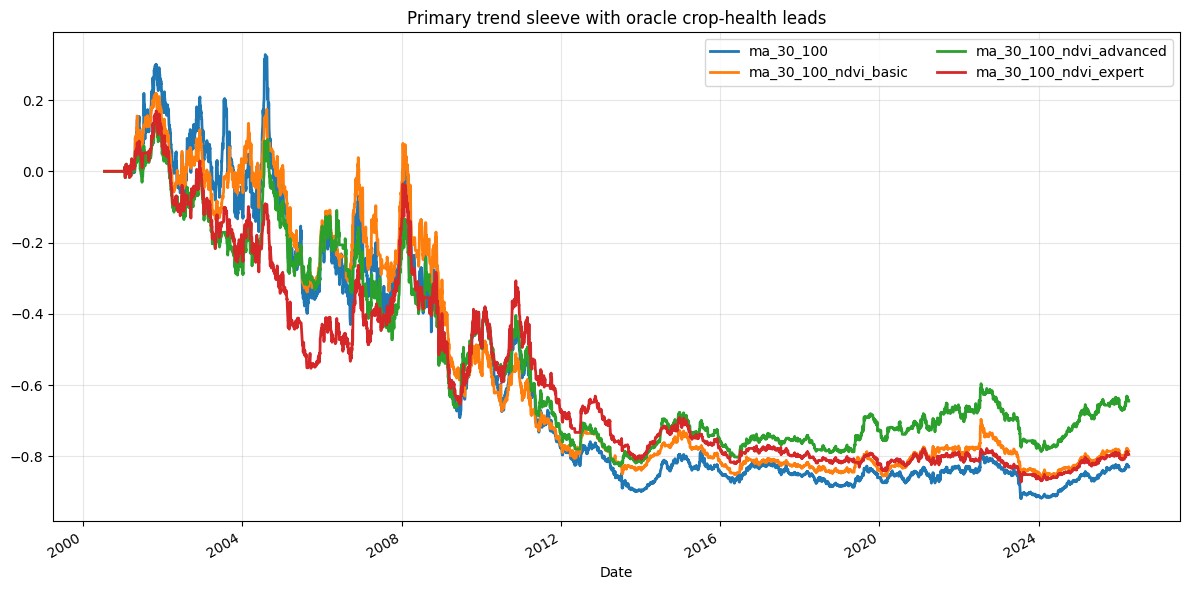

### Interpretation
- The best crop-health lead for the primary trend sleeve is `ma_30_100_ndvi_advanced` with Sharpe -0.06.
- This section is the cleanest answer to the question: how early must crop-health information arrive to improve a standard trend strategy?

In [97]:
display(trend_lead_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'ma_30_100': corn_ndvi['strategy_ret_30_100'],
        'ma_30_100_ndvi_basic': corn_ndvi['ma_30_100_ndvi_basic_return'],
        'ma_30_100_ndvi_advanced': corn_ndvi['ma_30_100_ndvi_advanced_return'],
        'ma_30_100_ndvi_expert': corn_ndvi['ma_30_100_ndvi_expert_return'],
    }),
    'Primary trend sleeve with oracle crop-health leads',
    figsize=(12, 6),
    ncol=2,
)

best_trend_lead = trend_lead_summary[[name.startswith('ma_30_100_ndvi_') for name in trend_lead_summary.index]]['ann_sharpe'].idxmax()
display_bullets(
    'Interpretation',
    [
        f'The best crop-health lead for the primary trend sleeve is `{best_trend_lead}` with Sharpe {trend_lead_summary.loc[best_trend_lead, "ann_sharpe"]:.2f}.',
        'This section is the cleanest answer to the question: how early must crop-health information arrive to improve a standard trend strategy?'
    ],
)

## Counter-trend strategy: create

Port the course counter-trend bounce rule into corn as its own independent sleeve.

In [98]:
countertrend = run_countertrend_strategy(corn, p=2.2)
register_strategy('countertrend_p2_2', countertrend['strategy_return'], countertrend['signal'])

countertrend_summary = summary_table([
    summarize_strategy('buy_and_hold', corn['futures_ret']),
    summarize_strategy('countertrend_p2_2', countertrend['strategy_return'], countertrend['signal']),
])

## Counter-trend strategy: evaluate

Check whether the bounce rule has enough standalone merit to justify testing crop-health overlays on top of it.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
countertrend_p2_2,6452,0.0373,0.1068,0.1996,-0.7333,0.6046


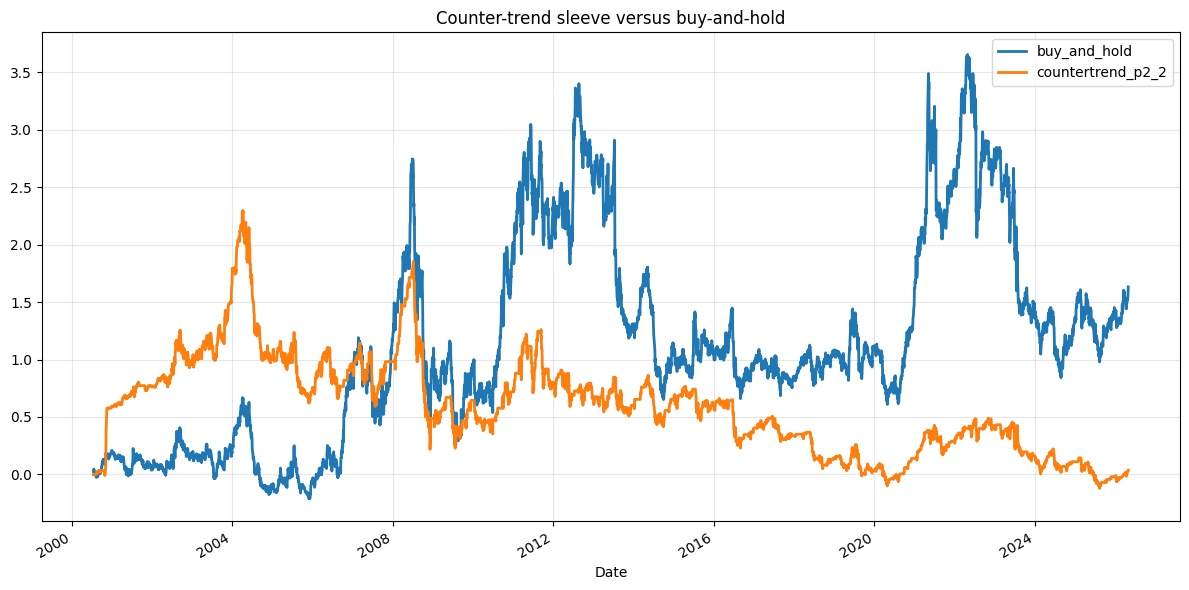

### Interpretation
- The counter-trend rule triggers 3901 long setups in the sample.
- Its standalone Sharpe is 0.11.

In [99]:
display(countertrend_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold': corn['futures_ret'],
        'countertrend_p2_2': countertrend['strategy_return'],
    }),
    'Counter-trend sleeve versus buy-and-hold',
    figsize=(12, 6),
    ncol=1,
)

trade_count = int(countertrend['signal'].sum())
display_bullets(
    'Interpretation',
    [
        f'The counter-trend rule triggers {trade_count} long setups in the sample.',
        f'Its standalone Sharpe is {countertrend_summary.loc["countertrend_p2_2", "ann_sharpe"]:.2f}.'
    ],
)

## Counter-trend strategy: apply crop-health leads

Because the counter-trend rule is long-only, poor future crop health should help while strong future crop health should veto or shrink the trade.

In [100]:
countertrend_overlap = countertrend.join(corn_ndvi[[f'crop_regime_{label}' for label in LEAD_SCENARIOS]], how='inner')
countertrend_lead_rows = [
    summarize_strategy('countertrend_p2_2', countertrend_overlap['strategy_return'], countertrend_overlap['signal']),
]

for label in LEAD_SCENARIOS:
    name = f'countertrend_p2_2_ndvi_{label}'
    filtered_signal = apply_regime_filter(countertrend_overlap['signal'], countertrend_overlap[f'crop_regime_{label}'])
    filtered_return = countertrend_overlap['strategy_return'].fillna(0.0) * filtered_signal.fillna(0.0)
    countertrend_overlap[f'{name}_signal'] = filtered_signal
    countertrend_overlap[f'{name}_return'] = filtered_return
    register_strategy(name, filtered_return, filtered_signal)
    countertrend_lead_rows.append(summarize_strategy(name, filtered_return, filtered_signal))

countertrend_lead_summary = summary_table(countertrend_lead_rows, sort=True)

## Evaluate NDVI-led counter-trend variants

This section asks whether forecasted crop stress is useful as a directional gate on short-horizon bounce trades.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
countertrend_p2_2_ndvi_advanced,6435,3.2343,0.4543,0.1486,-0.4602,0.4089
countertrend_p2_2_ndvi_basic,6435,2.6896,0.4253,0.1447,-0.4363,0.4027
countertrend_p2_2_ndvi_expert,6435,1.8134,0.3452,0.1497,-0.4419,0.4163
countertrend_p2_2,6435,0.0120,0.1021,0.1997,-0.7333,0.6040


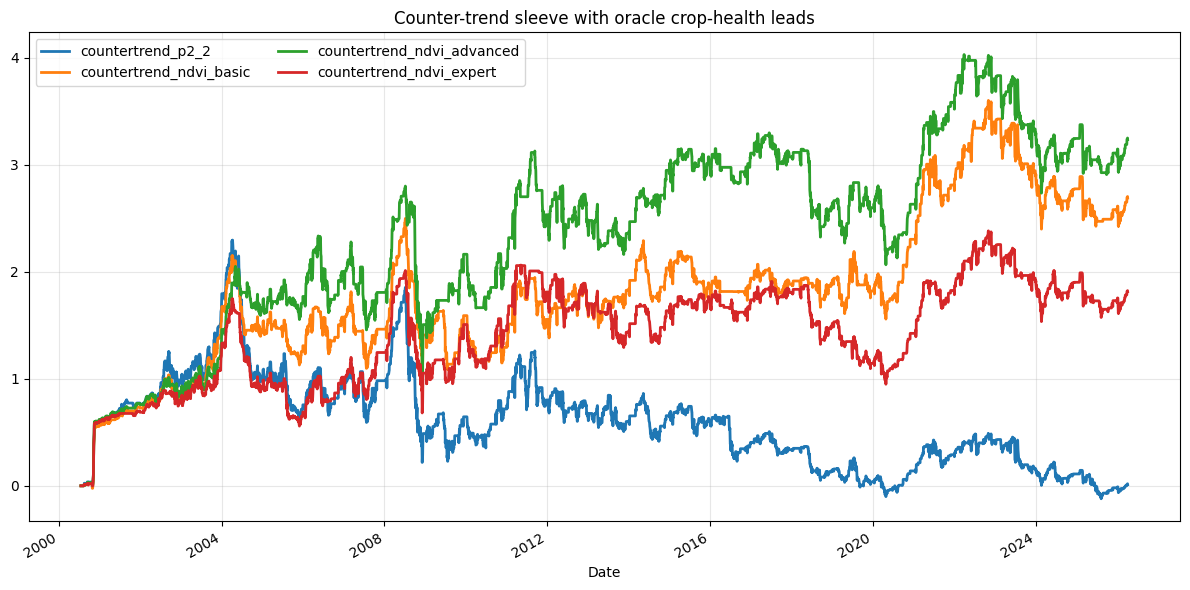

### Interpretation
- The strongest crop-health lead for the counter-trend sleeve is `countertrend_p2_2_ndvi_advanced` with Sharpe 0.45.
- If the counter-trend sleeve only improves at long leads, that suggests crop-health information matters slowly rather than tactically.

In [101]:
display(countertrend_lead_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'countertrend_p2_2': countertrend_overlap['strategy_return'],
        'countertrend_ndvi_basic': countertrend_overlap['countertrend_p2_2_ndvi_basic_return'],
        'countertrend_ndvi_advanced': countertrend_overlap['countertrend_p2_2_ndvi_advanced_return'],
        'countertrend_ndvi_expert': countertrend_overlap['countertrend_p2_2_ndvi_expert_return'],
    }),
    'Counter-trend sleeve with oracle crop-health leads',
    figsize=(12, 6),
    ncol=2,
)

best_countertrend_lead = countertrend_lead_summary[[name.startswith('countertrend_p2_2_ndvi_') for name in countertrend_lead_summary.index]]['ann_sharpe'].idxmax()
display_bullets(
    'Interpretation',
    [
        f'The strongest crop-health lead for the counter-trend sleeve is `{best_countertrend_lead}` with Sharpe {countertrend_lead_summary.loc[best_countertrend_lead, "ann_sharpe"]:.2f}.',
        'If the counter-trend sleeve only improves at long leads, that suggests crop-health information matters slowly rather than tactically.'
    ],
)

## Volatility regime strategy: create

Build the course volatility-regime sleeve as another independent directional strategy.

In [102]:
vol_regime = run_vol_regime_strategy(corn)
register_strategy('vol_regime', vol_regime['strategy_return'], vol_regime['signal'])

vol_summary = summary_table([
    summarize_strategy('buy_and_hold', corn['futures_ret']),
    summarize_strategy('vol_regime', vol_regime['strategy_return'], vol_regime['signal']),
])

## Volatility regime strategy: evaluate

Establish the volatility sleeve on its own before asking whether crop-health foresight improves it.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
vol_regime,6181,10.0235,0.4711,0.3108,-0.5660,1.0


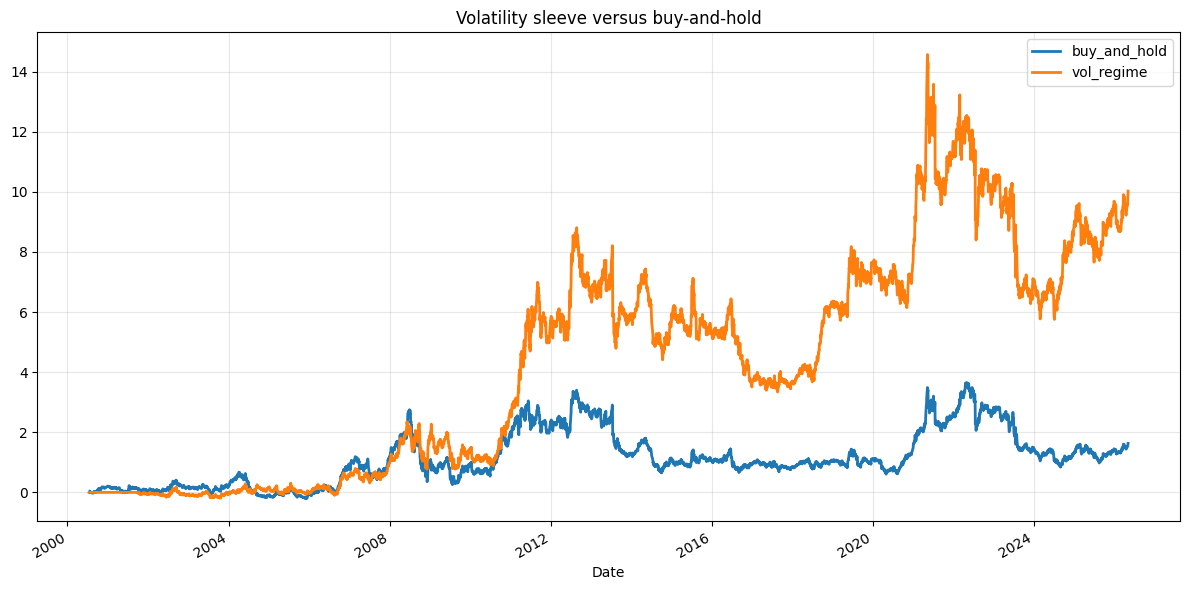

### Interpretation
- The standalone volatility-regime sleeve has Sharpe 0.47.
- This sleeve is useful because it is a directional rule that is economically different from both trend and counter-trend.

In [103]:
display(vol_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold': corn['futures_ret'],
        'vol_regime': vol_regime['strategy_return'],
    }),
    'Volatility sleeve versus buy-and-hold',
    figsize=(12, 6),
    ncol=1,
)

display_bullets(
    'Interpretation',
    [
        f'The standalone volatility-regime sleeve has Sharpe {vol_summary.loc["vol_regime", "ann_sharpe"]:.2f}.',
        'This sleeve is useful because it is a directional rule that is economically different from both trend and counter-trend.'
    ],
)

## Volatility regime strategy: apply crop-health leads

Use the same oracle lead framework on the volatility sleeve so the lead-horizon question is tested across multiple strategy families.

In [104]:
vol_overlap = vol_regime.join(corn_ndvi[[f'crop_regime_{label}' for label in LEAD_SCENARIOS]], how='inner')
vol_lead_rows = [
    summarize_strategy('vol_regime', vol_overlap['strategy_return'], vol_overlap['signal']),
]

for label in LEAD_SCENARIOS:
    name = f'vol_regime_ndvi_{label}'
    filtered_signal = apply_regime_filter(vol_overlap['signal'], vol_overlap[f'crop_regime_{label}'])
    filtered_panel = build_signal_strategy(filtered_signal, vol_overlap['futures_ret'], lag=1)
    vol_overlap[f'{name}_signal'] = filtered_panel['signal']
    vol_overlap[f'{name}_return'] = filtered_panel['strategy_return']
    register_strategy(name, filtered_panel['strategy_return'], filtered_panel['signal'])
    vol_lead_rows.append(summarize_strategy(name, filtered_panel['strategy_return'], filtered_panel['signal']))

vol_lead_summary = summary_table(vol_lead_rows, sort=True)

## Evaluate NDVI-led volatility variants

This is the third family-level check on whether crop-health information helps only one class of strategies or many of them.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
vol_regime_ndvi_advanced,6164,23.0118,0.6780,0.2310,-0.4313,0.7015
vol_regime_ndvi_expert,6164,12.6438,0.5764,0.2319,-0.3779,0.7035
vol_regime_ndvi_basic,6164,11.9855,0.5670,0.2326,-0.4648,0.7049
vol_regime,6164,9.4256,0.4645,0.3111,-0.5660,1.0000


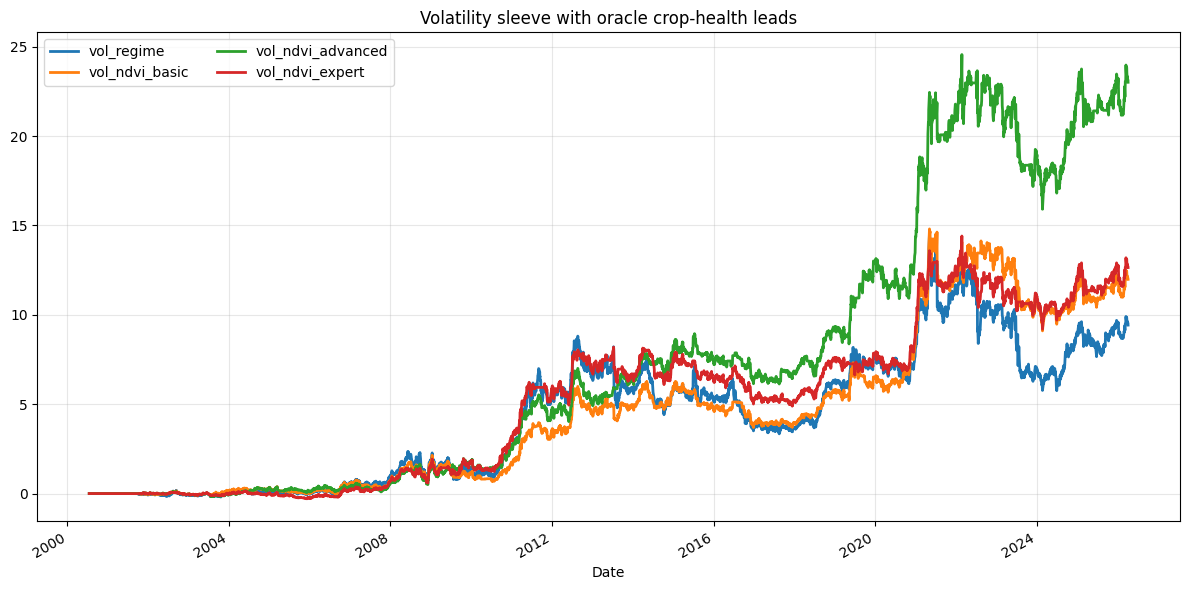

### Interpretation
- The strongest crop-health lead for the volatility sleeve is `vol_regime_ndvi_advanced` with Sharpe 0.68.
- If the same lead horizon wins repeatedly across sections, that gives a clearer story about what kind of weather-model edge would matter most.

In [105]:
display(vol_lead_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'vol_regime': vol_overlap['strategy_return'],
        'vol_ndvi_basic': vol_overlap['vol_regime_ndvi_basic_return'],
        'vol_ndvi_advanced': vol_overlap['vol_regime_ndvi_advanced_return'],
        'vol_ndvi_expert': vol_overlap['vol_regime_ndvi_expert_return'],
    }),
    'Volatility sleeve with oracle crop-health leads',
    figsize=(12, 6),
    ncol=2,
)

best_vol_lead = vol_lead_summary[[name.startswith('vol_regime_ndvi_') for name in vol_lead_summary.index]]['ann_sharpe'].idxmax()
display_bullets(
    'Interpretation',
    [
        f'The strongest crop-health lead for the volatility sleeve is `{best_vol_lead}` with Sharpe {vol_lead_summary.loc[best_vol_lead, "ann_sharpe"]:.2f}.',
        'If the same lead horizon wins repeatedly across sections, that gives a clearer story about what kind of weather-model edge would matter most.'
    ],
)

## Pairs study: test stationarity

Before building a pairs trade, test whether the corn-wheat spread behaves like a potentially mean-reverting series.

,value
df_tstat_regression,-4.4650
adf_stat,-3.9752
pvalue,0.0015
critical_10pct,-2.5670
critical_5pct,-2.8620
critical_1pct,-3.4314
observations,6412.0000


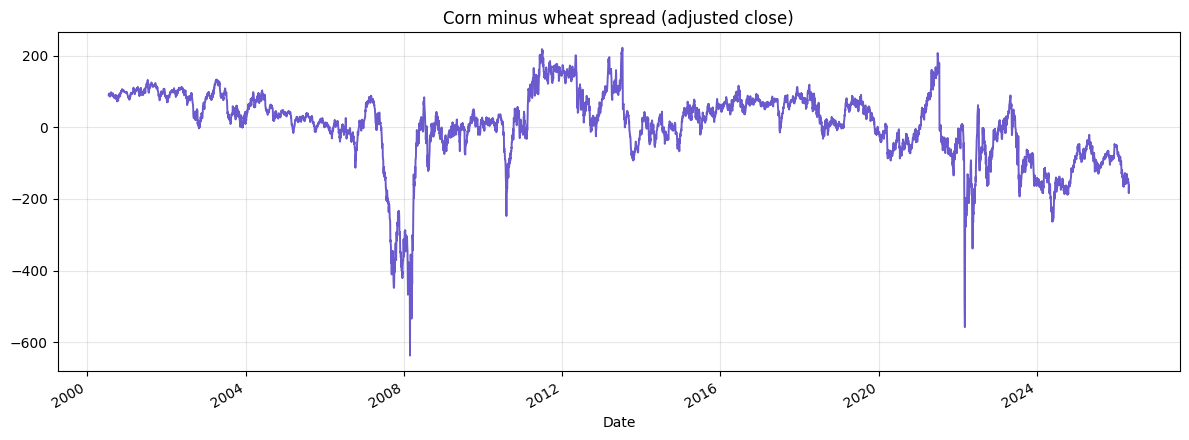

In [106]:
pairs_panel = pd.DataFrame()
pairs_diagnostics = None
pairs_strategy_summary = pd.DataFrame()

if wheat is None:
    display_bullets('Pairs section skipped', ['The wheat futures cache is missing, so no pairs study can be run in this notebook pass.'])
else:
    pairs_panel = build_pairs_panel(corn, wheat, horizons=PAIRS_HORIZONS)
    pairs_diagnostics = dickey_fuller_diagnostics(pairs_panel['spread_price'])
    display(pd.DataFrame([pairs_diagnostics]).T.rename(columns={0: 'value'}).round(4))

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pairs_panel['spread_price'].plot(ax=ax, color='slateblue', linewidth=1.4)
    ax.set_title('Corn minus wheat spread (adjusted close)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Pairs study: interpretation

A stationary-looking spread makes the pairs idea worth testing, and the corn-specific crop-health signal can be tested as a directional overlay on that relative-value trade.

In [107]:
if pairs_diagnostics is not None:
    stationary = pairs_diagnostics['pvalue'] < 0.05
    display_bullets(
        'Dickey-Fuller interpretation',
        [
            f'ADF p-value = {pairs_diagnostics["pvalue"]:.4f}.',
            'The spread looks stationary enough to justify a pairs test.' if stationary else 'The spread does not show strong stationarity, so the pairs sleeve should be treated cautiously.',
            'Because the spread is long corn versus short wheat, the crop-health signal can still matter directionally: weak forward corn crop health should favor long-spread trades, while strong crop health should favor short-spread trades.'
        ],
    )


### Dickey-Fuller interpretation
- ADF p-value = 0.0015.
- The spread looks stationary enough to justify a pairs test.
- Because the spread is long corn versus short wheat, the crop-health signal can still matter directionally: weak forward corn crop health should favor long-spread trades, while strong crop health should favor short-spread trades.

## Pairs strategy: build and run

Run the 5-day, 10-day, and 20-day pairs versions after the spread diagnostic is in place.

In [108]:
if not pairs_panel.empty:
    pairs_rows = []
    for horizon in PAIRS_HORIZONS:
        result = run_pairs_position_strategy(pairs_panel[f'zdiff{horizon}'], pairs_panel['future_spread_ret'])
        pairs_panel[f'pairs_ret_{horizon}'] = result['strategy_return']
        pairs_panel[f'pairs_pos_{horizon}'] = result['position']
        name = f'pairs_{horizon}d'
        register_strategy(name, pairs_panel[f'pairs_ret_{horizon}'], pairs_panel[f'pairs_pos_{horizon}'])
        pairs_rows.append(summarize_strategy(name, pairs_panel[f'pairs_ret_{horizon}'], pairs_panel[f'pairs_pos_{horizon}']))
    pairs_strategy_summary = summary_table(pairs_rows, sort=True)


## Pairs strategy: apply crop-health leads

Use the same `basic / advanced / expert` crop-health regimes as a directional overlay on the corn-wheat spread so the relative-value sleeve is tested under the same forecast-skill assumptions as the outright corn sleeves.

In [109]:
pairs_lead_summary = pd.DataFrame()
pairs_lead_plot_frame = pd.DataFrame()

if not pairs_panel.empty:
    pairs_regime_cols = [f'crop_regime_{label}' for label in LEAD_SCENARIOS]
    pairs_overlap = pairs_panel.join(corn_ndvi[pairs_regime_cols], how='inner')
    pairs_lead_rows = []

    for horizon in PAIRS_HORIZONS:
        base_position = pairs_overlap[f'pairs_pos_{horizon}']
        for label in LEAD_SCENARIOS:
            name = f'pairs_{horizon}d_ndvi_{label}'
            filtered_signal = apply_regime_filter(base_position, pairs_overlap[f'crop_regime_{label}'])
            filtered_return = filtered_signal * pairs_overlap['future_spread_ret']
            pairs_overlap[f'{name}_signal'] = filtered_signal
            pairs_overlap[f'{name}_return'] = filtered_return
            register_strategy(name, filtered_return, filtered_signal)
            pairs_lead_rows.append(summarize_strategy(name, filtered_return, filtered_signal))

    pairs_panel = pairs_overlap
    pairs_lead_summary = summary_table(pairs_lead_rows, sort=True)

    best_pairs_base = pairs_strategy_summary.index[0] if not pairs_strategy_summary.empty else None
    pairs_plot_cols = {}
    if best_pairs_base is not None:
        horizon = best_pairs_base.split('_')[1].replace('d', '')
        pairs_plot_cols[best_pairs_base] = pairs_panel[f'pairs_ret_{horizon}']
    for label in LEAD_SCENARIOS:
        candidate = f'pairs_5d_ndvi_{label}'
        if candidate in pairs_panel.columns:
            pairs_plot_cols[candidate] = pairs_panel[f'{candidate}_return']
    pairs_lead_plot_frame = pd.DataFrame(pairs_plot_cols)


## Evaluate NDVI-led pairs variants

Compare the raw pairs horizons and the NDVI-led pairs overlays, then decide whether the crop-health overlay materially improves the relative-value sleeve.

## Pairs strategy: evaluate

Compare the pairs holding horizons and the NDVI-led overlays, then decide whether the idea is strong enough to survive into the full cross-strategy comparison.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
pairs_5d,6415,0.0946,0.0905,0.1235,-0.4136,0.4882
pairs_10d,6415,0.0550,0.0784,0.1228,-0.4013,0.4737
pairs_20d,6415,-0.4835,-0.1459,0.1247,-0.6430,0.4842


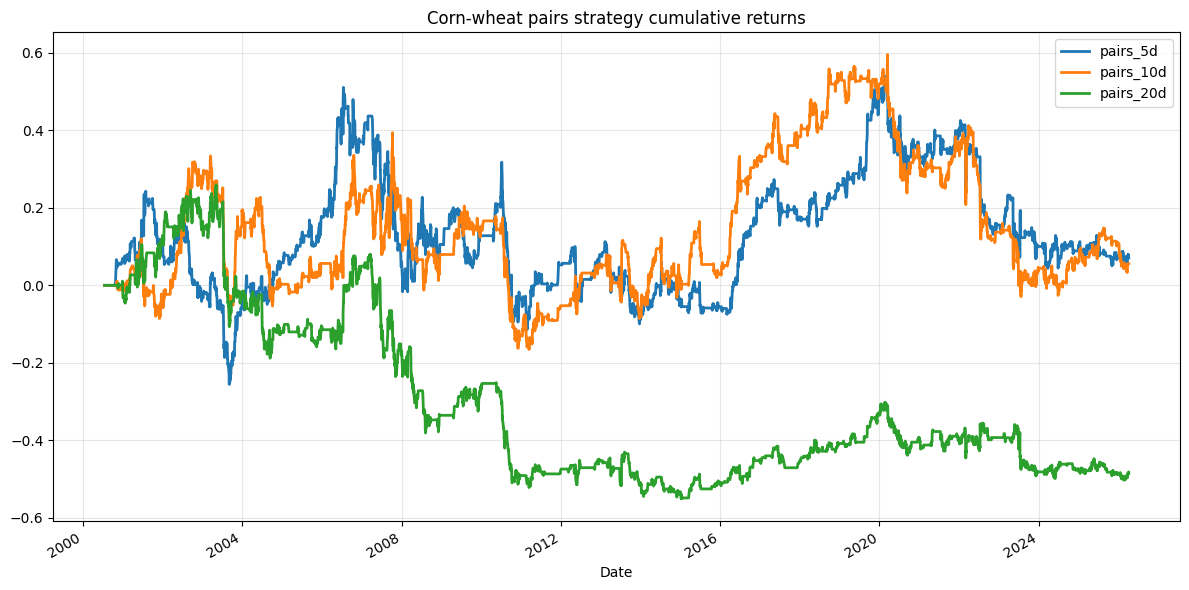

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
pairs_5d_ndvi_basic,6399,0.7059,0.2764,0.0911,-0.3384,0.3359
pairs_10d_ndvi_basic,6399,0.5252,0.2309,0.0892,-0.3016,0.3291
pairs_5d_ndvi_expert,6399,0.3604,0.1762,0.0936,-0.2861,0.3357
pairs_10d_ndvi_advanced,6399,0.1607,0.1094,0.0927,-0.2914,0.3267
pairs_5d_ndvi_advanced,6399,0.0094,0.0499,0.0917,-0.3304,0.3338
pairs_10d_ndvi_expert,6399,-0.0142,0.0404,0.0931,-0.3450,0.3275
pairs_20d_ndvi_basic,6399,-0.0800,0.0087,0.0903,-0.4499,0.3324
pairs_20d_ndvi_expert,6399,-0.2086,-0.0535,0.0925,-0.4661,0.3349
pairs_20d_ndvi_advanced,6399,-0.2165,-0.0563,0.0935,-0.4587,0.3350


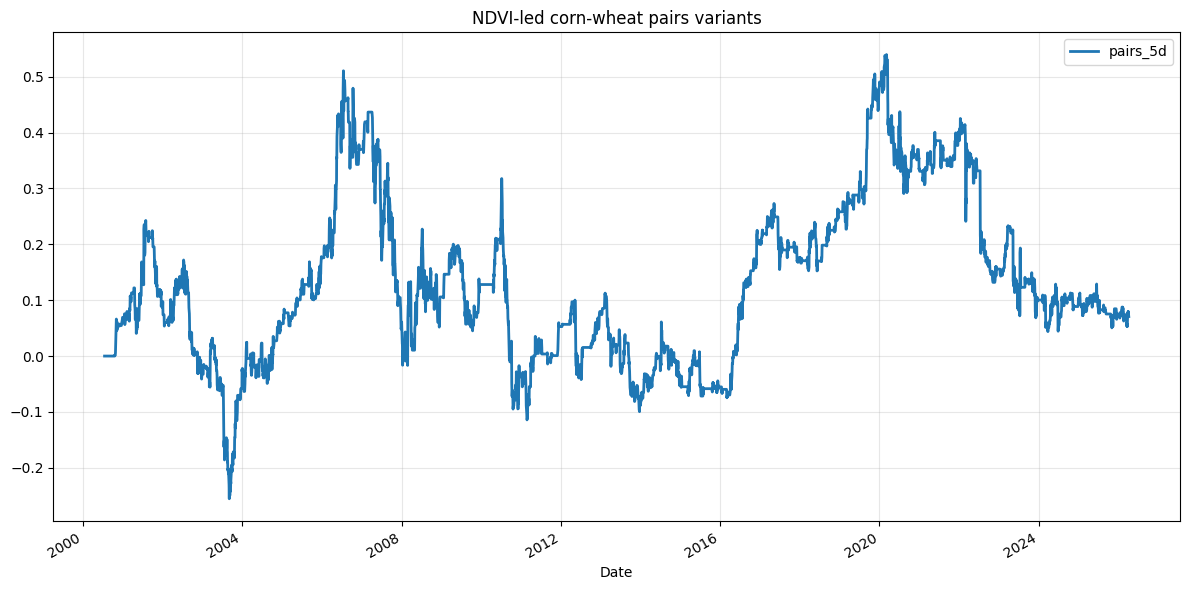

### Interpretation
- The best base pairs horizon is `pairs_5d` with Sharpe 0.09.
- The strongest NDVI-led pairs sleeve is `pairs_5d_ndvi_basic` with Sharpe 0.28.
- This is the cleanest way to test whether crop-health foresight improves the relative performance of corn against wheat rather than only improving outright corn timing.

In [110]:
if pairs_strategy_summary.empty:
    display_bullets('Pairs evaluation', ['No pairs strategy results are available because the pairs section was skipped.'])
else:
    display(pairs_strategy_summary)

    plot_cumulative_returns(
        pd.DataFrame({
            'pairs_5d': pairs_panel['pairs_ret_5'],
            'pairs_10d': pairs_panel['pairs_ret_10'],
            'pairs_20d': pairs_panel['pairs_ret_20'],
        }),
        'Corn-wheat pairs strategy cumulative returns',
        figsize=(12, 6),
        ncol=1,
    )

    if not pairs_lead_summary.empty:
        display(pairs_lead_summary)
        plot_cumulative_returns(
            pairs_lead_plot_frame,
            'NDVI-led corn-wheat pairs variants',
            figsize=(12, 6),
            ncol=2,
        )
        best_pairs_filtered = pairs_lead_summary.index[0]
        filtered_text = f'The strongest NDVI-led pairs sleeve is `{best_pairs_filtered}` with Sharpe {pairs_lead_summary.iloc[0]["ann_sharpe"]:.2f}.'
    else:
        filtered_text = 'No NDVI-led pairs variants were generated in this notebook pass.'

    best_pairs = pairs_strategy_summary['ann_sharpe'].idxmax()
    display_bullets(
        'Interpretation',
        [
            f'The best base pairs horizon is `{best_pairs}` with Sharpe {pairs_strategy_summary.loc[best_pairs, "ann_sharpe"]:.2f}.',
            filtered_text,
            'This is the cleanest way to test whether crop-health foresight improves the relative performance of corn against wheat rather than only improving outright corn timing.'
        ],
    )


## Compare all strategy sleeves

The table below compares every standalone sleeve and every NDVI-led variant. The plot is intentionally more selective so it stays readable.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
vol_regime_ndvi_advanced,6164,23.0118,0.6780,0.2310,-0.4313,0.7015
vol_regime_ndvi_expert,6164,12.6438,0.5764,0.2319,-0.3779,0.7035
vol_regime_ndvi_basic,6164,11.9855,0.5670,0.2326,-0.4648,0.7049
vol_regime,6181,10.0235,0.4711,0.3108,-0.5660,1.0000
countertrend_p2_2_ndvi_advanced,6435,3.2343,0.4543,0.1486,-0.4602,0.4089
ndvi_oracle_advanced,6434,3.7248,0.4328,0.1759,-0.5678,0.2687
countertrend_p2_2_ndvi_basic,6435,2.6896,0.4253,0.1447,-0.4363,0.4027
countertrend_p2_2_ndvi_expert,6435,1.8134,0.3452,0.1497,-0.4419,0.4163
ma_10_30,6421,2.7582,0.3231,0.3082,-0.5738,1.0000


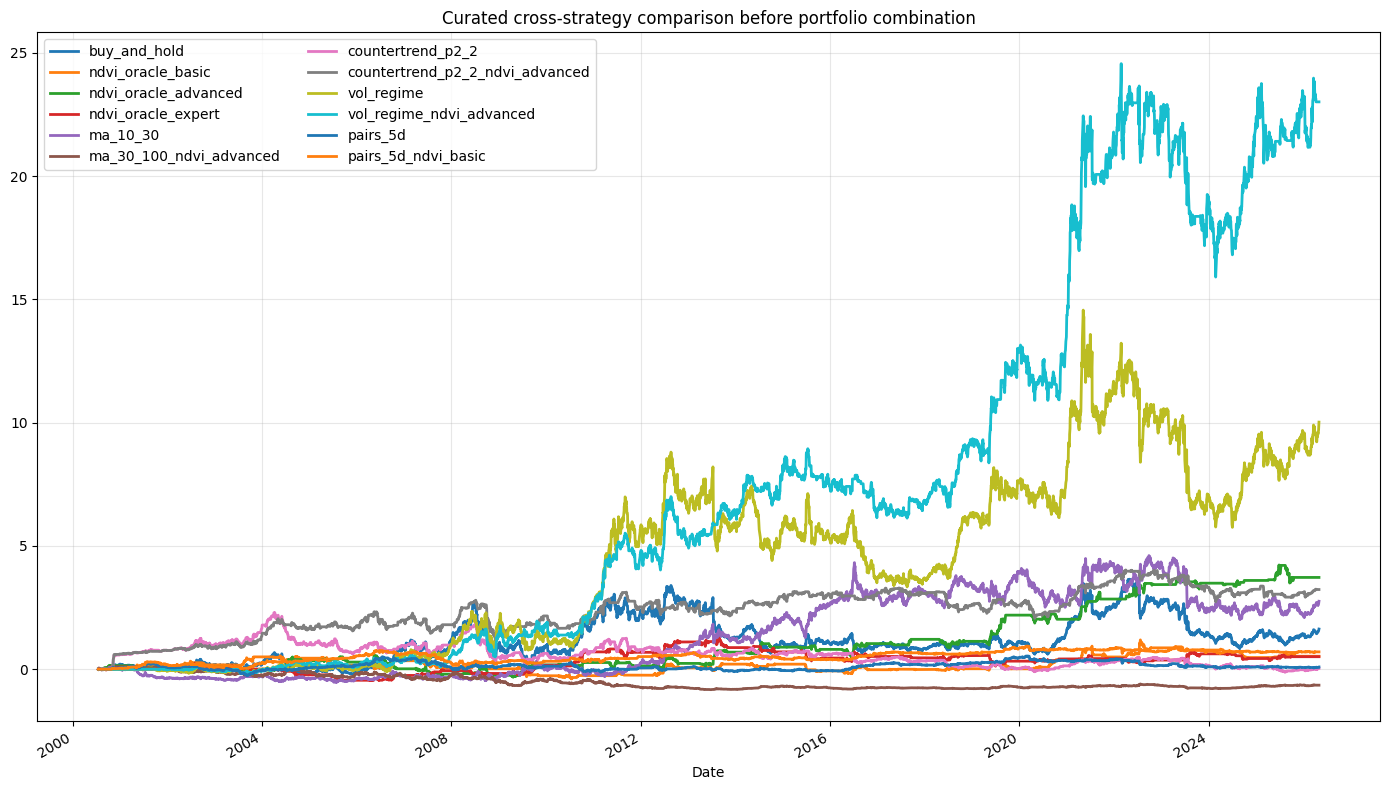

### Comparison takeaway
- The top Sharpe sleeve in the current notebook pass is `vol_regime_ndvi_advanced` at 0.68.
- The strongest crop-health lead on the standalone oracle signal is `ndvi_oracle_advanced`.
- The strongest crop-health-led pairs sleeve is `pairs_5d_ndvi_basic`.
- These sleeves are the ingredient set for the optimized raw-combination search in the next section.

In [111]:
comparison_summary = pd.DataFrame(strategy_summary_map.values()).set_index('strategy').sort_values('ann_sharpe', ascending=False).round(4)
display(comparison_summary)

best_filtered_trend = trend_lead_summary[[name.startswith('ma_30_100_ndvi_') for name in trend_lead_summary.index]]['ann_sharpe'].idxmax()
best_filtered_countertrend = countertrend_lead_summary[[name.startswith('countertrend_p2_2_ndvi_') for name in countertrend_lead_summary.index]]['ann_sharpe'].idxmax()
best_filtered_vol = vol_lead_summary[[name.startswith('vol_regime_ndvi_') for name in vol_lead_summary.index]]['ann_sharpe'].idxmax()
best_pairs_name = pairs_strategy_summary.index[0] if not pairs_strategy_summary.empty else None
best_filtered_pairs = pairs_lead_summary.index[0] if not pairs_lead_summary.empty else None

curated_plot_names = [
    'buy_and_hold',
    'ndvi_oracle_basic',
    'ndvi_oracle_advanced',
    'ndvi_oracle_expert',
    best_plain_trend,
    best_filtered_trend,
    'countertrend_p2_2',
    best_filtered_countertrend,
    'vol_regime',
    best_filtered_vol,
]
if best_pairs_name is not None:
    curated_plot_names.append(best_pairs_name)
if best_filtered_pairs is not None:
    curated_plot_names.append(best_filtered_pairs)

curated_plot_names = [name for name in curated_plot_names if name in strategy_return_streams]
curated_returns = pd.DataFrame({name: strategy_return_streams[name] for name in curated_plot_names})
plot_cumulative_returns(
    curated_returns,
    'Curated cross-strategy comparison before portfolio combination',
    figsize=(14, 8),
    ncol=2,
)

display_bullets(
    'Comparison takeaway',
    [
        f'The top Sharpe sleeve in the current notebook pass is `{comparison_summary.index[0]}` at {comparison_summary.iloc[0]["ann_sharpe"]:.2f}.',
        f'The strongest crop-health lead on the standalone oracle signal is `{lead_summary.index[0]}`.',
        f'The strongest crop-health-led pairs sleeve is `{best_filtered_pairs}`.' if best_filtered_pairs is not None else 'No crop-health-led pairs sleeve was available in this notebook pass.',
        'These sleeves are the ingredient set for the optimized raw-combination search in the next section.'
    ],
)


## Raw strategy combination: candidate universe

Now move from individual sleeves to portfolio construction. The goal is to search across the raw strategy set and allow diversification to matter, including the possibility that a weak standalone sleeve can still improve Sharpe if it offsets losses elsewhere.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share,family
strategy,,,,,,,
vol_regime,6159,9.6234,0.4671,0.3112,-0.5660,1.0000,volatility
ma_10_30,6159,4.0804,0.3698,0.3112,-0.4664,1.0000,trend
ma_80_160,6159,0.1339,0.1728,0.3113,-0.8763,1.0000,trend
pairs_10d,6159,0.0737,0.0849,0.1226,-0.4013,0.4767,pairs
pairs_5d,6159,-0.1149,0.0210,0.1231,-0.4136,0.4912,pairs
countertrend_p2_2,6159,-0.4390,-0.0183,0.1999,-0.7339,0.5990,countertrend
ma_30_100,6159,-0.8563,-0.0985,0.3113,-0.9389,1.0000,trend
pairs_20d,6159,-0.5251,-0.1825,0.1245,-0.6430,0.4884,pairs


,dataset,rows,start,end,strategies
0,raw strategy optimization sample,6159,2001-10-02,2026-04-07,8


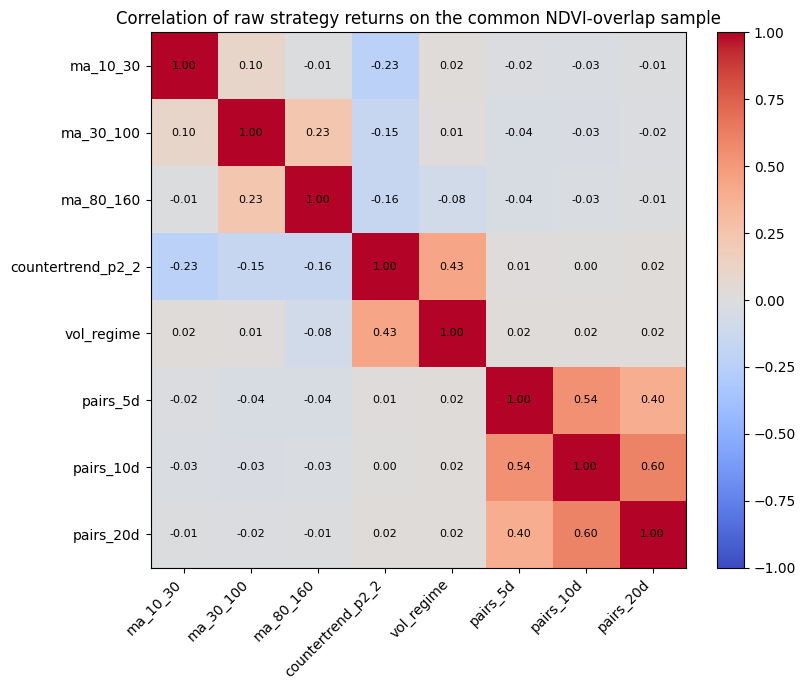

### Why optimize on this sample
- All raw sleeves are aligned to the common period where the NDVI series exists so the later weather-overlay comparison is apples-to-apples.
- The optimizer is allowed to keep a weak standalone sleeve if its correlation pattern improves the overall portfolio Sharpe.
- Buy-and-hold remains a benchmark, but the combination search is focused on the systematic sleeves themselves.

In [112]:
raw_strategy_specs = {
    'ma_10_30': {
        'returns': corn_ndvi['strategy_ret_10_30'],
        'signal': corn_ndvi['signal_10_30'],
        'signal_lag': 1,
        'family': 'trend',
    },
    'ma_30_100': {
        'returns': corn_ndvi['strategy_ret_30_100'],
        'signal': corn_ndvi['signal_30_100'],
        'signal_lag': 1,
        'family': 'trend',
    },
    'ma_80_160': {
        'returns': corn_ndvi['strategy_ret_80_160'],
        'signal': corn_ndvi['signal_80_160'],
        'signal_lag': 1,
        'family': 'trend',
    },
    'countertrend_p2_2': {
        'returns': countertrend['strategy_return'],
        'signal': countertrend['signal'],
        'signal_lag': 0,
        'family': 'countertrend',
    },
    'vol_regime': {
        'returns': vol_regime['strategy_return'],
        'signal': vol_regime['signal'],
        'signal_lag': 1,
        'family': 'volatility',
    },
}

if not pairs_panel.empty:
    raw_strategy_specs.update({
        'pairs_5d': {
            'returns': pairs_panel['pairs_ret_5'],
            'signal': pairs_panel['pairs_pos_5'],
            'signal_lag': 0,
            'family': 'pairs',
        },
        'pairs_10d': {
            'returns': pairs_panel['pairs_ret_10'],
            'signal': pairs_panel['pairs_pos_10'],
            'signal_lag': 0,
            'family': 'pairs',
        },
        'pairs_20d': {
            'returns': pairs_panel['pairs_ret_20'],
            'signal': pairs_panel['pairs_pos_20'],
            'signal_lag': 0,
            'family': 'pairs',
        },
    })

raw_candidate_returns = pd.DataFrame({
    name: pd.Series(spec['returns']).reindex(corn_ndvi.index)
    for name, spec in raw_strategy_specs.items()
})
raw_candidate_signals = pd.DataFrame({
    name: pd.Series(spec['signal']).reindex(corn_ndvi.index)
    for name, spec in raw_strategy_specs.items()
})
raw_candidate_families = pd.Series({name: spec['family'] for name, spec in raw_strategy_specs.items()}, name='family')
raw_optimization_frame = raw_candidate_returns.dropna()

raw_candidate_rows = [
    summarize_strategy(name, raw_optimization_frame[name], raw_candidate_signals.loc[raw_optimization_frame.index, name])
    for name in raw_optimization_frame.columns
]
raw_candidate_summary = summary_table(raw_candidate_rows, sort=True)
raw_candidate_summary = raw_candidate_summary.join(raw_candidate_families)
display(raw_candidate_summary)

display(pd.DataFrame([
    {
        'dataset': 'raw strategy optimization sample',
        'rows': len(raw_optimization_frame),
        'start': raw_optimization_frame.index.min().date(),
        'end': raw_optimization_frame.index.max().date(),
        'strategies': raw_optimization_frame.shape[1],
    }
]))

corr = raw_optimization_frame.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title('Correlation of raw strategy returns on the common NDVI-overlap sample')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display_bullets(
    'Why optimize on this sample',
    [
        'All raw sleeves are aligned to the common period where the NDVI series exists so the later weather-overlay comparison is apples-to-apples.',
        'The optimizer is allowed to keep a weak standalone sleeve if its correlation pattern improves the overall portfolio Sharpe.',
        'Buy-and-hold remains a benchmark, but the combination search is focused on the systematic sleeves themselves.'
    ],
)


## Raw strategy combination: optimize the portfolio

Search across every non-empty subset of the raw strategy universe. For each subset, choose long-only weights that maximize annualized Sharpe on the common evaluation sample. This keeps the exercise academically clean: any improvement must come from diversification and weighting, not from shorting weak strategies into new ones.

,effective_size,active_strategies,ann_return,ann_vol,ann_sharpe,cum_return,max_drawdown
0,4,ma_10_30 + ma_80_160 + vol_regime + pairs_10d,0.0967,0.1524,0.6343,6.9749,-0.3605
16,4,ma_10_30 + ma_80_160 + vol_regime + pairs_5d,0.1094,0.1742,0.6279,8.9586,-0.3739
24,3,ma_10_30 + ma_80_160 + vol_regime,0.1163,0.1853,0.6273,10.2158,-0.3833
32,3,ma_10_30 + vol_regime + pairs_10d,0.1061,0.1780,0.5959,8.0552,-0.3755
48,3,ma_10_30 + vol_regime + pairs_5d,0.1254,0.2126,0.5897,11.2878,-0.4066
56,2,ma_10_30 + vol_regime,0.1321,0.2241,0.5894,12.6001,-0.4188
64,3,ma_80_160 + vol_regime + pairs_10d,0.0925,0.1780,0.5197,5.4975,-0.4161
80,3,ma_80_160 + vol_regime + pairs_5d,0.1097,0.2136,0.5134,7.3239,-0.4532
88,2,ma_80_160 + vol_regime,0.1174,0.2289,0.5130,8.2572,-0.4874
96,2,vol_regime + pairs_10d,0.1056,0.2230,0.4734,6.1734,-0.4702


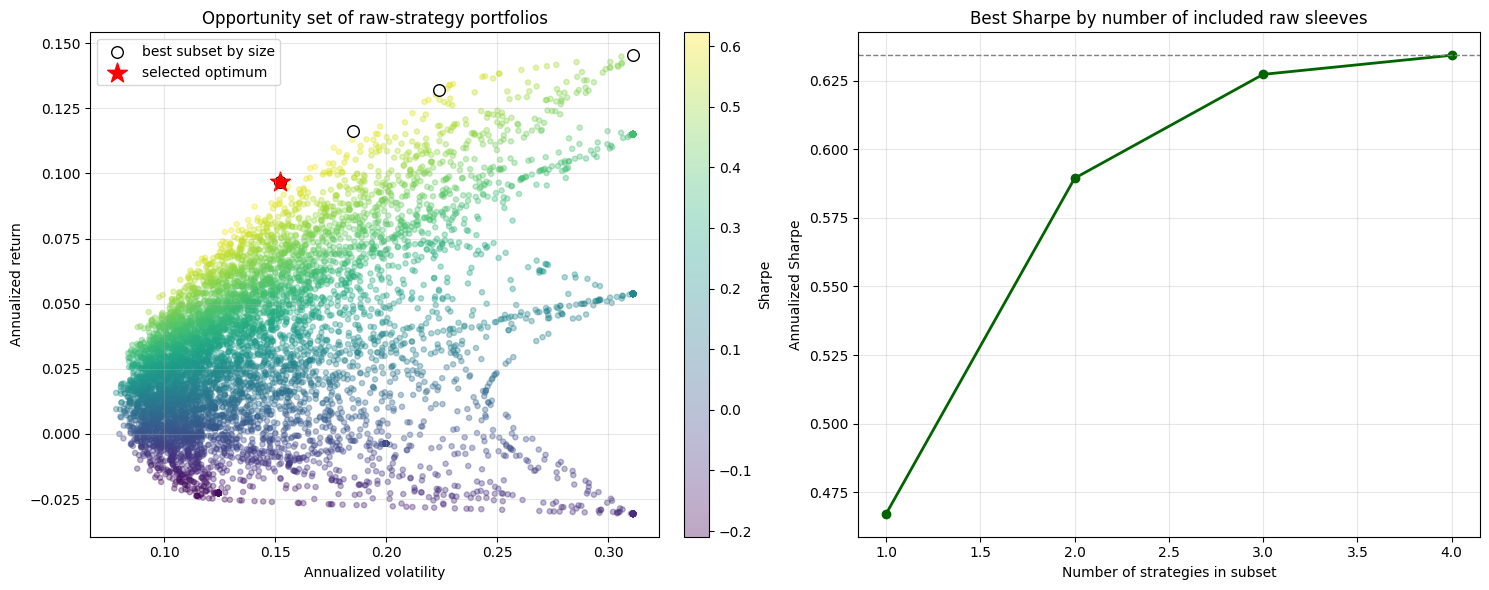

,weight
vol_regime,0.3671
ma_10_30,0.2809
pairs_10d,0.1837
ma_80_160,0.1683


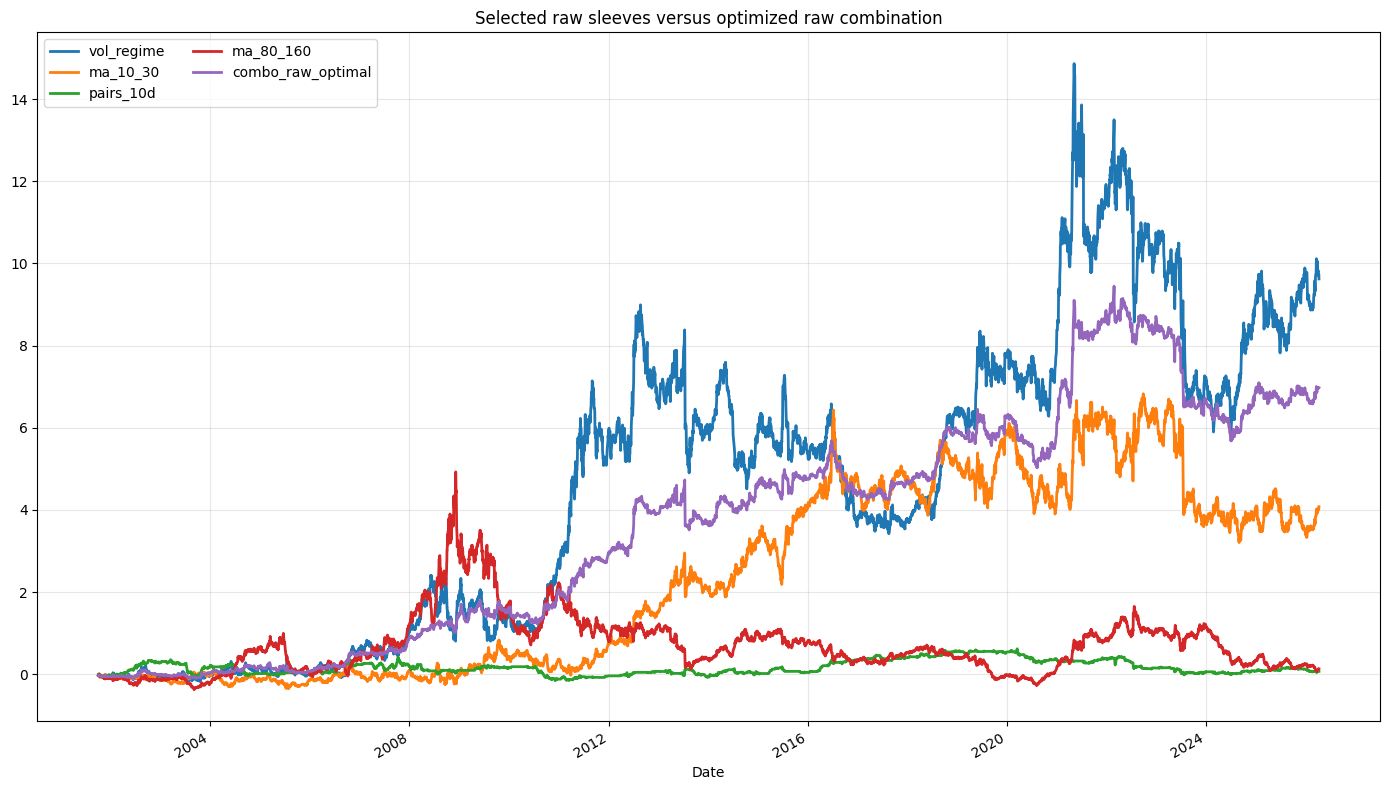

### Selected raw combination
- Selected raw combination Sharpe = 0.63 on the common NDVI-overlap sample.
- Chosen effective sleeve count = 4.
- vol_regime: 36.7%
- ma_10_30: 28.1%
- pairs_10d: 18.4%
- ma_80_160: 16.8%
- The best portfolio did not need a negative-Sharpe sleeve once the correlation structure was taken into account.

In [113]:
raw_subset_results = optimize_strategy_subsets(raw_optimization_frame)
raw_subset_display = raw_subset_results[['effective_size', 'active_strategies', 'ann_return', 'ann_vol', 'ann_sharpe', 'cum_return', 'max_drawdown']].drop_duplicates(subset=['active_strategies']).head(15).round(4)
display(raw_subset_display)

best_by_size_idx = raw_subset_results.groupby('effective_size')['ann_sharpe'].idxmax()
best_by_size = raw_subset_results.loc[best_by_size_idx].sort_values('effective_size').reset_index(drop=True)
random_frontier = sample_random_portfolios(raw_optimization_frame, n_samples=8000, random_state=7)

best_raw_combo_row = raw_subset_results.iloc[0]
selected_raw_weights = extract_weight_series(best_raw_combo_row, raw_optimization_frame.columns)
selected_raw_names = list(selected_raw_weights.index)
selected_component_frame = raw_optimization_frame[selected_raw_names].copy()
raw_combo_returns = selected_component_frame.dot(selected_raw_weights.reindex(selected_raw_names))
register_strategy('combo_raw_optimal', raw_combo_returns)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter = axes[0].scatter(
    random_frontier['ann_vol'],
    random_frontier['ann_return'],
    c=random_frontier['ann_sharpe'],
    cmap='viridis',
    alpha=0.35,
    s=14,
)
axes[0].scatter(best_by_size['ann_vol'], best_by_size['ann_return'], color='white', edgecolor='black', s=70, label='best subset by size')
axes[0].scatter(best_raw_combo_row['ann_vol'], best_raw_combo_row['ann_return'], color='red', marker='*', s=220, label='selected optimum')
axes[0].set_title('Opportunity set of raw-strategy portfolios')
axes[0].set_xlabel('Annualized volatility')
axes[0].set_ylabel('Annualized return')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
fig.colorbar(scatter, ax=axes[0], fraction=0.046, pad=0.04, label='Sharpe')

axes[1].plot(best_by_size['effective_size'], best_by_size['ann_sharpe'], marker='o', linewidth=2, color='darkgreen')
axes[1].axhline(best_raw_combo_row['ann_sharpe'], color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Best Sharpe by number of included raw sleeves')
axes[1].set_xlabel('Number of strategies in subset')
axes[1].set_ylabel('Annualized Sharpe')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(selected_raw_weights.rename('weight').to_frame().round(4))
plot_cumulative_returns(
    pd.concat([selected_component_frame, raw_combo_returns.rename('combo_raw_optimal')], axis=1),
    'Selected raw sleeves versus optimized raw combination',
    figsize=(14, 8),
    ncol=2,
)

negative_contributors = [
    name for name in selected_raw_names
    if raw_candidate_summary.loc[name, 'ann_sharpe'] < 0
]

selection_lines = [
    f'Selected raw combination Sharpe = {best_raw_combo_row["ann_sharpe"]:.2f} on the common NDVI-overlap sample.',
    f'Chosen effective sleeve count = {int(best_raw_combo_row["effective_size"])}.',
]
selection_lines.extend([f'{name}: {weight:.1%}' for name, weight in selected_raw_weights.items()])
if negative_contributors:
    selection_lines.append('At least one negative standalone sleeve survived because it improved diversification: ' + ', '.join(negative_contributors) + '.')
else:
    selection_lines.append('The best portfolio did not need a negative-Sharpe sleeve once the correlation structure was taken into account.')

display_bullets('Selected raw combination', selection_lines)


## Apply weather-prediction tiers to the selected combination

Hold the raw portfolio weights fixed, then apply the `basic`, `advanced`, and `expert` crop-health lead regimes to that chosen combination. This isolates the value of weather-model skill from the value of raw strategy diversification.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,sharpe_uplift
strategy,,,,,,
combo_raw_optimal,6159,6.9749,0.6343,0.1524,-0.3605,0.0000
combo_raw_optimal_ndvi_basic,6159,5.0944,0.6245,0.1324,-0.2945,-0.0098
combo_raw_optimal_ndvi_advanced,6159,8.7247,0.7829,0.1296,-0.2095,0.1486
combo_raw_optimal_ndvi_expert,6159,4.9551,0.6225,0.1310,-0.2796,-0.0118


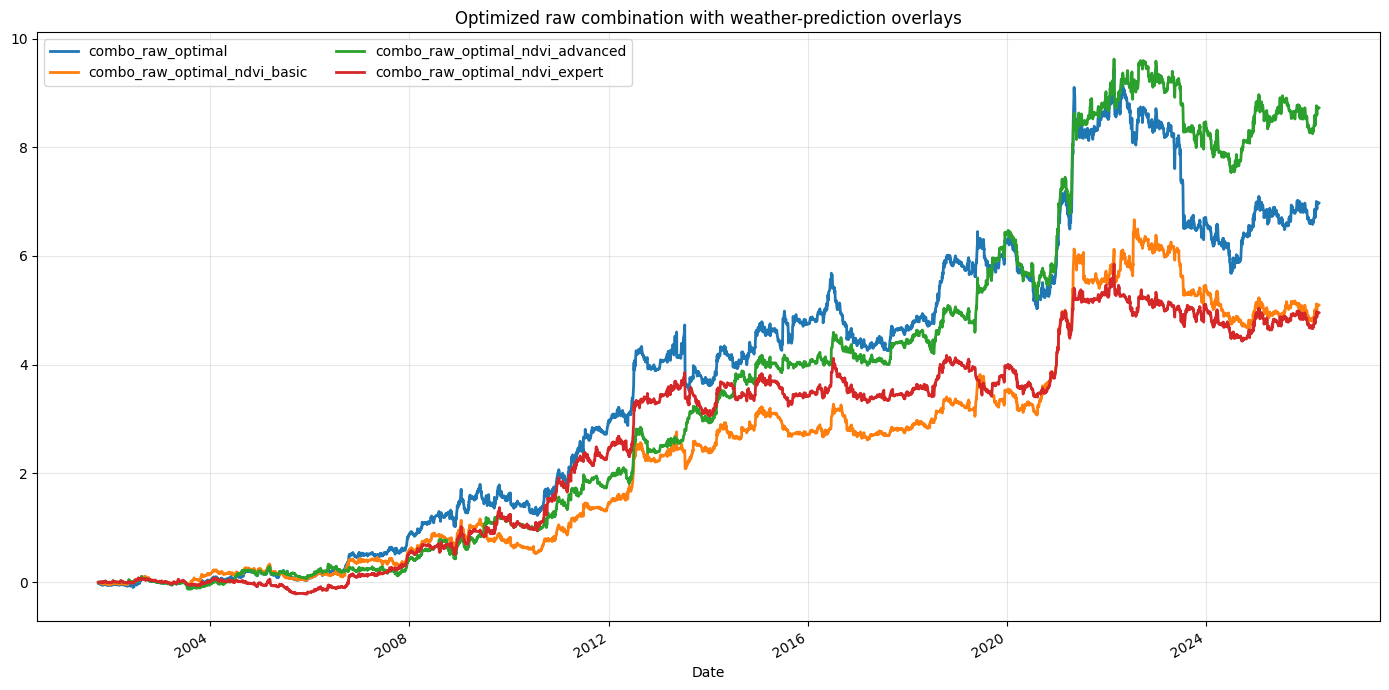

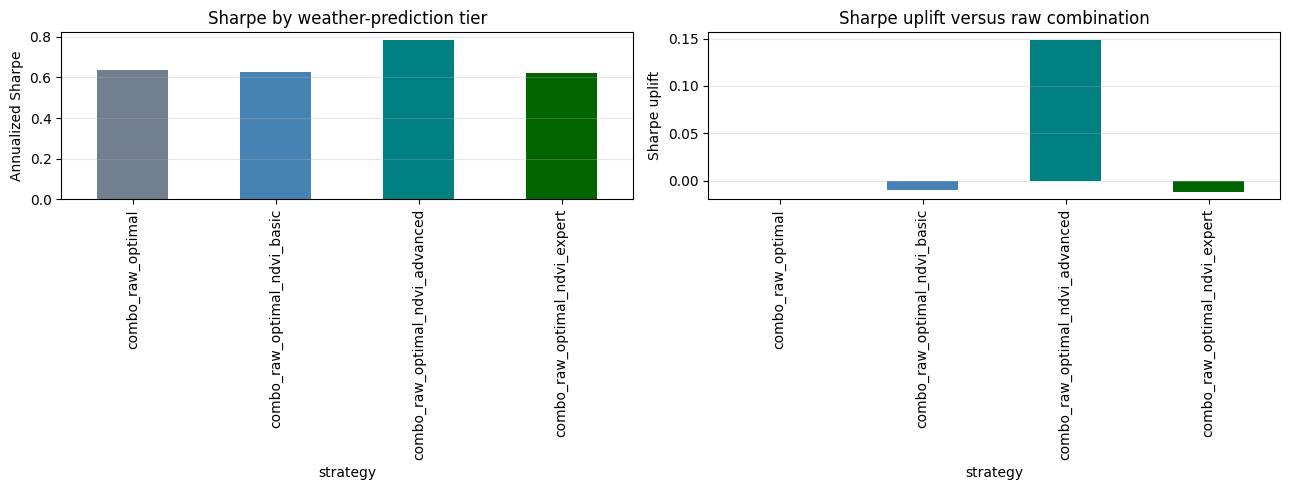

### Weather-overlay takeaway
- The fixed-weight raw combination has Sharpe 0.63.
- The best weather tier for that same combination is `combo_raw_optimal_ndvi_advanced` with Sharpe 0.78.
- Because the underlying weights are held fixed, any Sharpe improvement here can be attributed to crop-health foresight rather than to re-optimizing the base strategy mix.
- This is the cleanest way to separate raw diversification skill from theoretical weather-model skill.

In [114]:
combo_variant_series = {
    'combo_raw_optimal': raw_combo_returns,
}

for label in LEAD_SCENARIOS:
    filtered_components = {}
    for name in selected_raw_names:
        spec = raw_strategy_specs[name]
        variant = apply_regime_to_strategy_returns(
            signal=pd.Series(spec['signal']).reindex(corn_ndvi.index),
            base_return=pd.Series(spec['returns']).reindex(corn_ndvi.index),
            regime=corn_ndvi[f'crop_regime_{label}'],
            signal_lag=spec['signal_lag'],
        )
        filtered_components[name] = variant['strategy_return']
    filtered_frame = pd.DataFrame(filtered_components)
    combo_name = f'combo_raw_optimal_ndvi_{label}'
    combo_variant_series[combo_name] = filtered_frame[selected_raw_names].dot(selected_raw_weights.reindex(selected_raw_names))

combo_variant_frame = pd.DataFrame(combo_variant_series).dropna()
combo_variant_rows = []
for name in combo_variant_frame.columns:
    register_strategy(name, combo_variant_frame[name])
    combo_variant_rows.append(summarize_strategy(name, combo_variant_frame[name]))
combo_variant_summary = summary_table(combo_variant_rows, sort=False)
base_combo_sharpe = combo_variant_summary.loc['combo_raw_optimal', 'ann_sharpe']
combo_variant_summary['sharpe_uplift'] = (combo_variant_summary['ann_sharpe'] - base_combo_sharpe).round(4)
display(combo_variant_summary)

plot_cumulative_returns(
    combo_variant_frame,
    'Optimized raw combination with weather-prediction overlays',
    figsize=(14, 7),
    ncol=2,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
combo_variant_summary['ann_sharpe'].plot(kind='bar', ax=axes[0], color=['slategray', 'steelblue', 'teal', 'darkgreen'])
axes[0].set_title('Sharpe by weather-prediction tier')
axes[0].set_ylabel('Annualized Sharpe')
axes[0].grid(True, axis='y', alpha=0.3)

combo_variant_summary['sharpe_uplift'].plot(kind='bar', ax=axes[1], color=['gray', 'steelblue', 'teal', 'darkgreen'])
axes[1].set_title('Sharpe uplift versus raw combination')
axes[1].set_ylabel('Sharpe uplift')
axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_overlay_name = combo_variant_summary['ann_sharpe'].idxmax()

display_bullets(
    'Weather-overlay takeaway',
    [
        f'The fixed-weight raw combination has Sharpe {base_combo_sharpe:.2f}.',
        f'The best weather tier for that same combination is `{best_overlay_name}` with Sharpe {combo_variant_summary.loc[best_overlay_name, "ann_sharpe"]:.2f}.',
        'Because the underlying weights are held fixed, any Sharpe improvement here can be attributed to crop-health foresight rather than to re-optimizing the base strategy mix.',
        'This is the cleanest way to separate raw diversification skill from theoretical weather-model skill.'
    ],
)


## Notes

- The NASA crop-health signal in this notebook is a seasonally adjusted anomaly, not a raw NDVI level.
- The `basic`, `advanced`, and `expert` lead tests are forecast-skill tiers rather than literal guaranteed forecasts.
- Future realized NDVI anomaly is used as a perfect-foresight benchmark for what a strong weather-model operation might approximate, not as a live tradable signal.
- Raw-strategy combination is optimized before the weather overlay so the notebook cleanly separates diversification value from crop-health information value.
- The final weather-overlay comparison keeps the raw portfolio weights fixed and only changes the crop-health information set.
